# TITULO

## 1. Introduccion

### 1.1 Contexto
Encuenta realiza en Argentina entre estudiantes en 2018

### 1.2 Objetivo
El objetivo principal de la tercera Encuesta Mundial de Salud Escolar 2018 (EMSE 2018) fue proporcionar datos precisos sobre comportamientos relativos a la salud y los factores de riesgo y de protección entre estudiantes de Argentina

### 1.3 Tamaño
El dataset ocupa aproximadamente 100 MB y contiene 57K filas

## 2. Carga e Inspeccion Inicial

### 2.1 Importacion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import json
from IPython.display import display
from scipy.stats import entropy
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA

### 2.2 Carga del Dataset

In [2]:
# Cargamos un diccionario con las traducciones de los codigos de preguntas
with open("data/traducciones.json", "r") as file:
    traducciones = json.load(file)
    traducciones_df = pd.DataFrame(traducciones.items())

# Cargamos el dataset con los datos
df = pd.read_csv("data/EMSE_DatosAbiertos.csv")

### 2.3 Informacion General

In [3]:
df.shape

(56981, 309)

In [4]:
df.isna().sum()

sitio              0
record             0
q1               108
texto_q1         108
q2               536
                ... 
qnpe5g          1949
texto_qnpe5g       0
weight             0
stratum            0
psu                0
Length: 309, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Columns: 309 entries, sitio to psu
dtypes: float64(154), int64(3), object(152)
memory usage: 134.3+ MB


Observamos que el dataset cuenta con 56981 filas y 309 columnas o features.

In [6]:
df.head()

,sitio,record,q1,texto_q1,q2,texto_q2,q3,texto_q3,q4,q5,...,texto_qnpa5g,qnpa7g,texto_qnpa7g,qnpe3g,texto_qnpe3g,qnpe5g,texto_qnpe5g,weight,stratum,psu
0,AG,1,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,NaN,NaN,...,Si,1.0,Si,2.0,No,2.0,No,457.09,201801010,19
1,AG,2,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,NaN,NaN,...,Si,2.0,No,2.0,No,2.0,No,457.09,201801010,19
2,AG,3,4.0,14 años,1.0,Masculino,4.0,2do año/11vo grado nivel Polimodal o 4to año n...,1.67,56.0,...,Si,2.0,No,2.0,No,2.0,No,261.44,201801010,19
3,AG,4,6.0,16 años,1.0,Masculino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,1.73,70.0,...,No,2.0,No,1.0,Si,1.0,Si,550.90,201801010,19
4,AG,5,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,NaN,NaN,...,No,2.0,No,2.0,No,2.0,No,457.09,201801010,19


## 3. Comprension de Variables

Se puede observar que el dataset cuenta con 2 columnas para cada pregunta del cuestionario, una numerica y una codificada en texto. Todas las respuestas a las preguntas son de tipo **categorica** y tienen asociado su correspondiente lista de codigos validos presentes en la documentacion.

In [7]:
# Obtenemos todas las columnas que comiencen con "q", 
# aquellas que representan un pregunta del cuestionario.
# Evitamos las columnas que representan la misma pregunta pero con
# su respuesta en formato textual.
df[df.columns[pd.Series(df.columns).str.startswith('q')]].columns

Index(['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q10', 'q15', 'q16', 'q17',
       ...
       'qnff2g', 'qnff3g', 'qntob2g', 'qnnotb2g', 'qnbcanyg', 'qnc1g',
       'qnpa5g', 'qnpa7g', 'qnpe3g', 'qnpe5g'],
      dtype='object', length=153)

Observamos entonces que el cuestionario cuenta con 153 preguntas.

## 4. Preseleccion de Variables

Para simplificar el analisis vamos a hacer una preseleccion de las variables que consideramos, a grandes razgos, que podrian estar relacionadas al objetivo final.

In [8]:
from matplotlib.ticker import PercentFormatter
from textwrap import fill

def get_colors(n):
    return plt.cm.tab20(np.arange(n))

def missing_correlation(questions, figsize):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle("Analisis de Datos Faltantes")

    ax1.set_title("Correlación de Datos Faltantes")
    msno.heatmap(df[questions], ax=ax1, fontsize=11)

    ax2.set_title("Matriz de Datos Faltantes")
    msno.matrix(df[questions], ax=ax2, sparkline=False, fontsize=11)

    plt.tight_layout()
    plt.show()

def entropy_stats(q):
    series = df[q].dropna()
    
    # Calculamos entropía
    counts = series.value_counts() # Cuento ocurrencias de cada categoría
    pi = counts / counts.sum() # Calculo las pi (frecuencias relativas)
    
    # Entropía máxima (si todas las categorías ocurrieran con la misma probabilidad)
    h_max = np.log2(series.nunique())
    
    # Entropía de Shannon con Scipi
    h_shannon = entropy(pi, base=2)
    return h_shannon, h_max

def questions_summary(questions, figsize=(12, 5)):
    for q in questions:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        fig.suptitle(f"{q}: {traducciones.get(q, q)}")

        # --- Plot 1: Value frequencies as percentages ---
        h, h_max = entropy_stats(q)
        ax1.text(
            0.03, 0.95, 
            f"Entropia Maxima: {h_max:.2f}\nEntropia de Shannon: {h:.2f}", 
            transform=ax1.transAxes, 
            horizontalalignment='left', 
            verticalalignment='top',
            fontsize=10,
            bbox = dict(
                boxstyle="round,pad=0.5",      # Rounded corners with padding
                facecolor="white",             # Legend background color
                edgecolor="lightgrey",         # Subtle grey outline matching standard legends
                linewidth=1                    # Border thickness
            )
        )

        sns.countplot(x=q, data=df.dropna(subset=[q]), hue=q, palette='pastel', ax=ax1, stat="count")
        ax1.get_legend().remove()
        
        labels = df[[q, "texto_" + q]].dropna(subset=[q]).drop_duplicates().sort_values(by=q)["texto_" + q].dropna()
        labels = [fill(label, width=24) for label in labels]
        ax1.set_xticks(range(len(labels)))
        ax1.set_xticklabels(labels, rotation=45, ha='right')

        # --- Plot 2: NaN vs Non-NaN percentages ---
        counts = df[q].isna().value_counts()
        counts = counts.reindex([True, False]).fillna(0)
        counts.index = ["Nulos", "No Nulos"]
        
        ax2.pie(
            counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            startangle=0,
            colors=sns.color_palette('pastel')
        )
        
        ax2.set_title("Distribucion de Nulos")
        ax2.axis('equal') # Asegura que el gráfico sea circular
    
        plt.tight_layout()
        plt.show()

    if len(questions) > 1:
        missing_correlation(questions, figsize)

### 4.1 Definicion del Target

Como objetivo de este trabajo se propone preparar los datos para poder predecir si un estudiante se encuentra **en riesgo** de cometer suicidio o no.
Para ello, definimos a la variable target como una derivacion de las features **q25** y **q26**.

In [9]:
print("q25:", traducciones["q25"])

display(df[["q25", "texto_q25"]].sort_values(by="q25").drop_duplicates())

print("q26:", traducciones["q26"])
display(df[["q26", "texto_q26"]].sort_values(by="q26").drop_duplicates())

q25: Durante los últimos 12 meses, ¿hiciste algún plan de cómo intentarías suicidarte?


,q25,texto_q25
18392,1.0,Si
38774,2.0,No
184,NaN,Dato perdido


q26: Durante los últimos 12 meses, ¿cuántas veces intentaste realmente suicidarte?


,q26,texto_q26
0,1.0,0 veces
27900,2.0,1 vez
2247,3.0,2 o 3 veces
670,4.0,4 o 5 veces
52410,5.0,6 o más veces
86,NaN,Dato perdido


Como se puede ver, ambas features son categoricas. En el caso de *q25*, se trata de una categorica binaria, mientras que *q26* se trata de una categorica ordinal.

Para la definicion de nuestra variable target diremos que un estudiante se encuentra en riesgo, si:
1. Hizo algun plan de como suicidarse en los ultimos 12 meses, o
2. se intento suicidar al menos 1 vez.

Luego podemos definir nuestra variable target como:

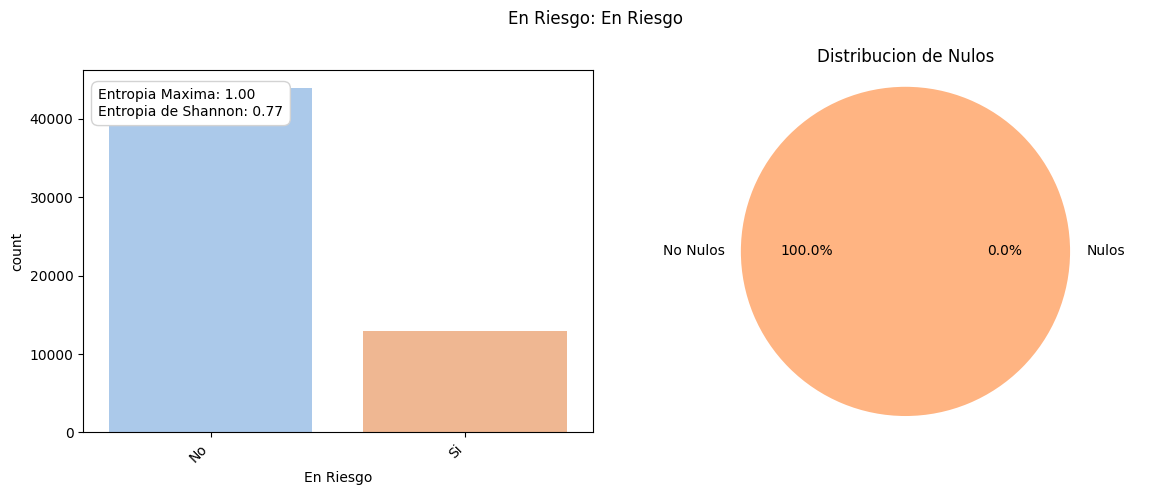

In [10]:
target = "En Riesgo"
df[target] = np.where((df["q25"] == 1) | (df["q26"] >= 2), 1, 0)
df["texto_" + target] = np.where(df[target] == 1, "Si", "No")

questions_summary([target])

### 4.2 Variables Demograficas

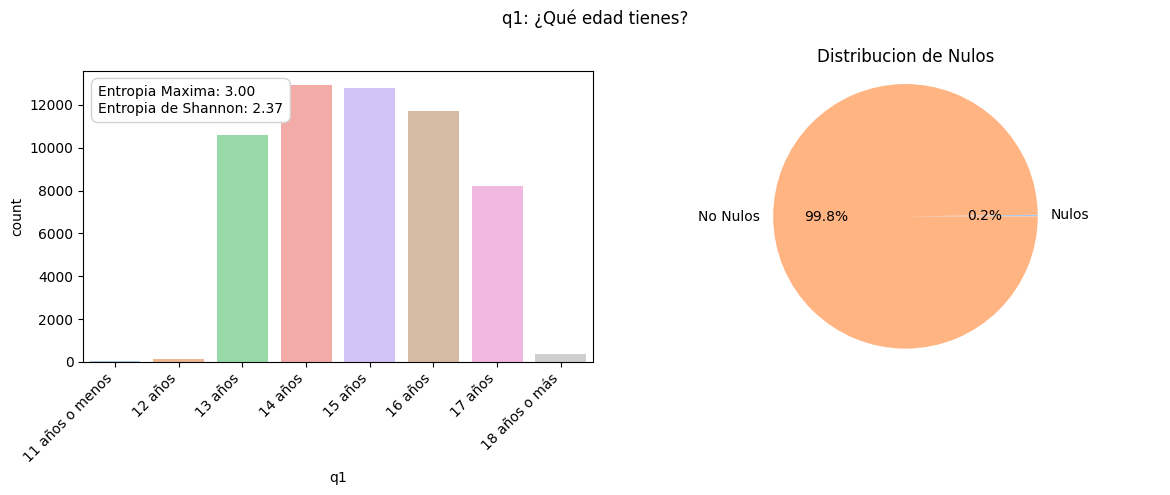

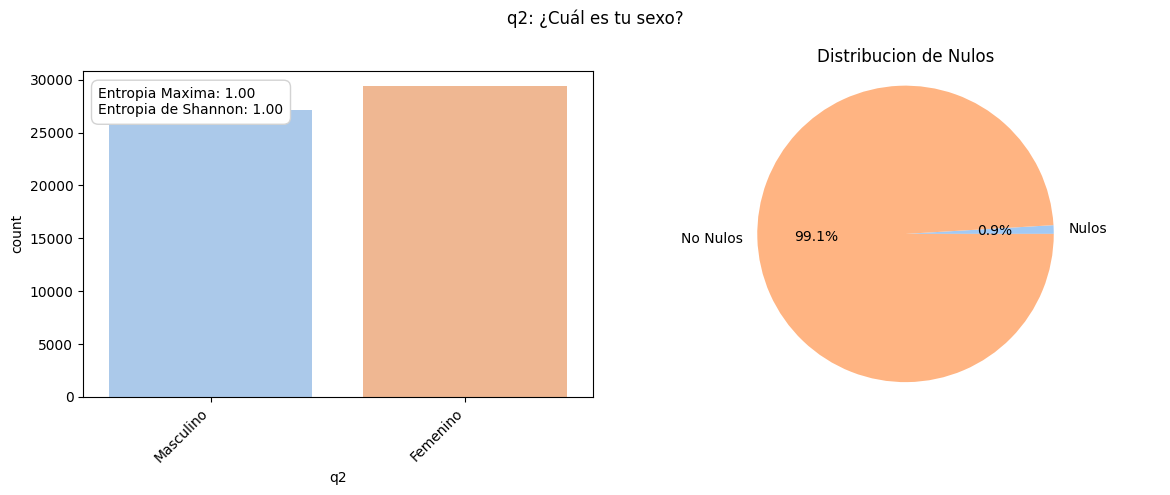

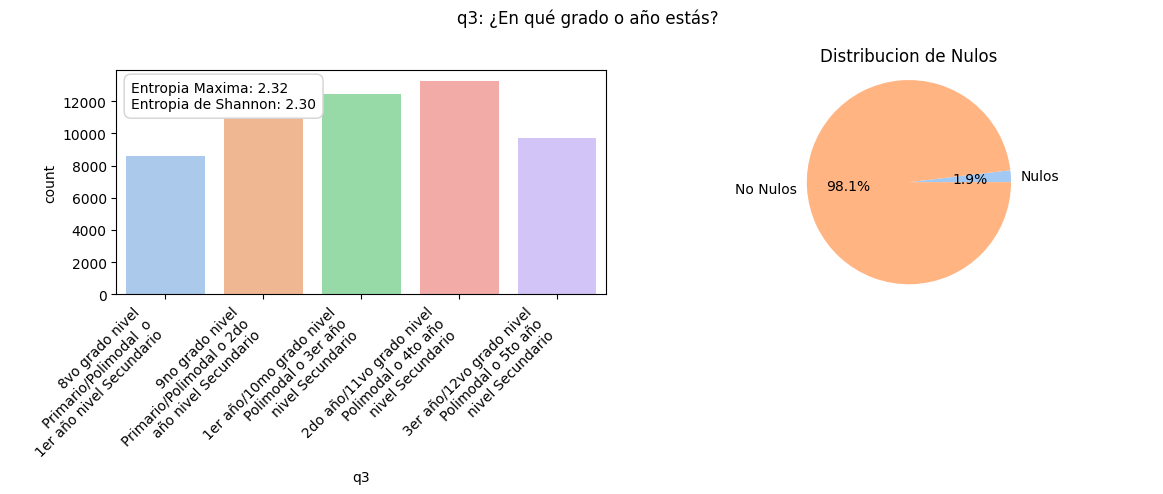

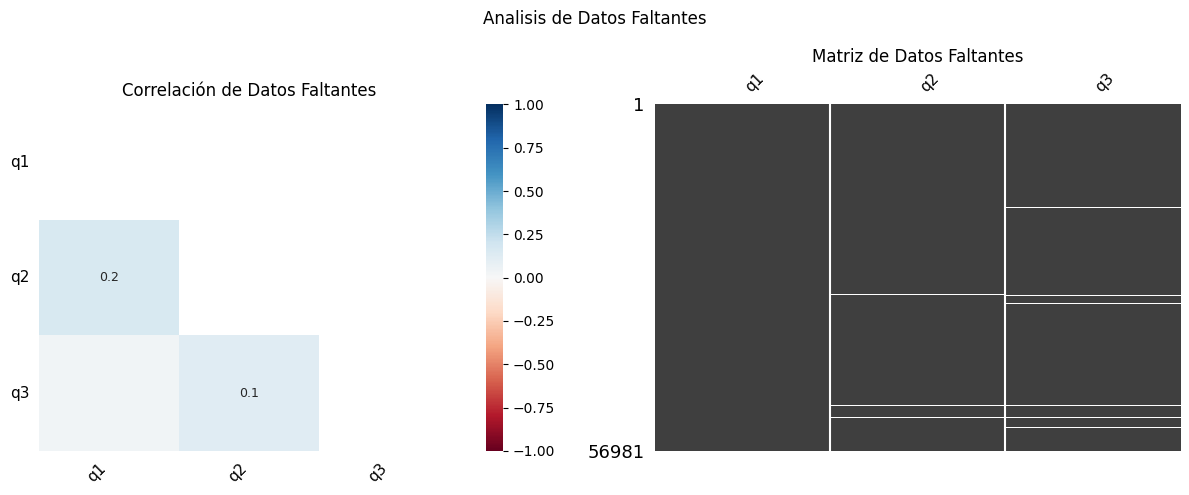

In [11]:
demograficas = ["q1", "q2", "q3"]
questions_summary(demograficas)

### 4.3 Variables de Salud Mental

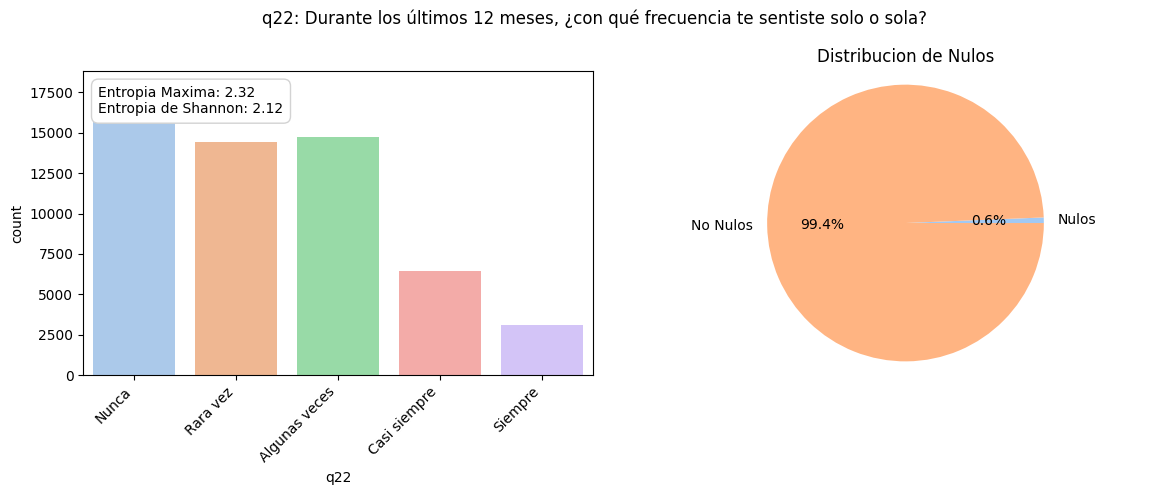

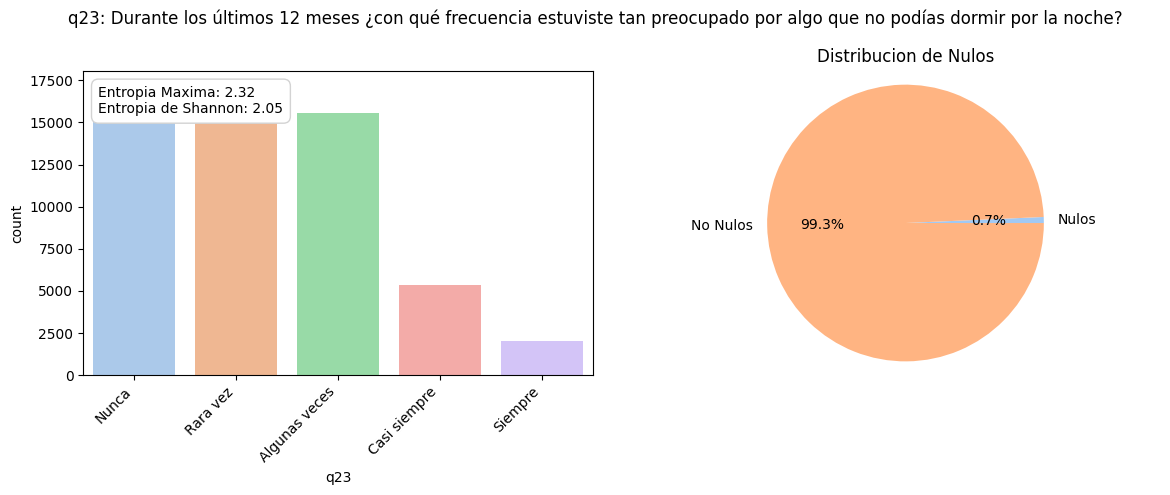

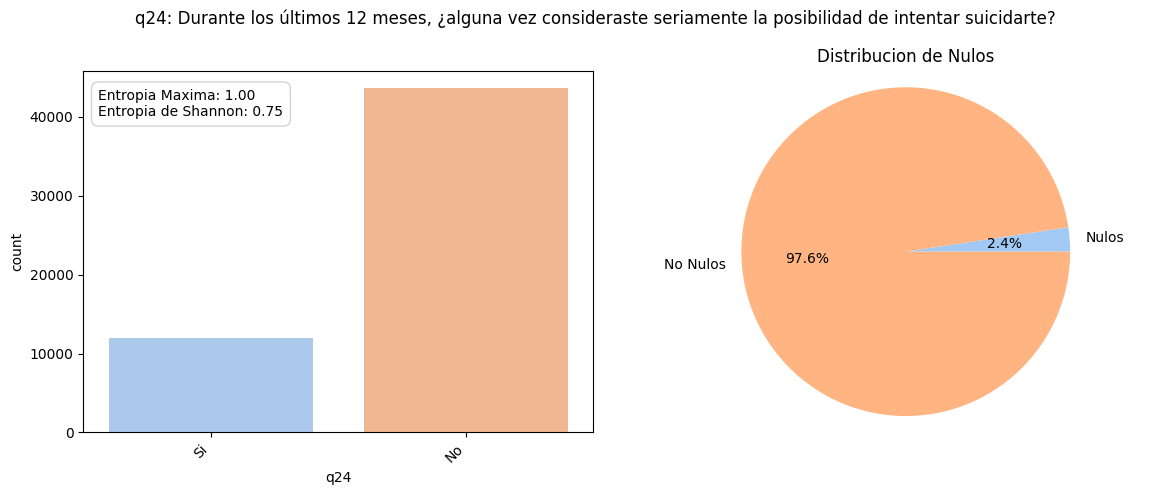

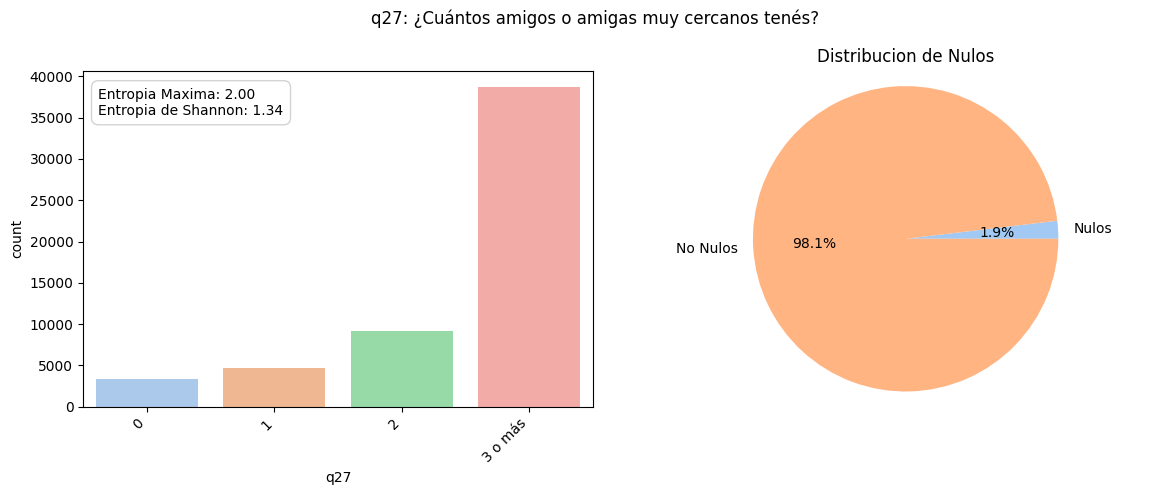

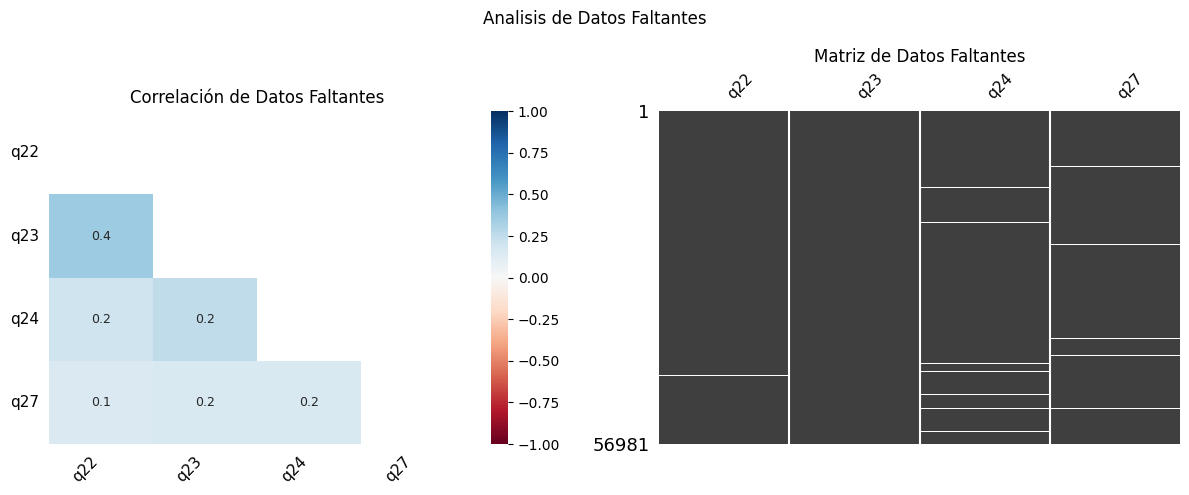

In [12]:
salud_mental = ["q22", "q23", "q24", "q27"]
questions_summary(salud_mental)

### 4.4 Violencia y Bullying

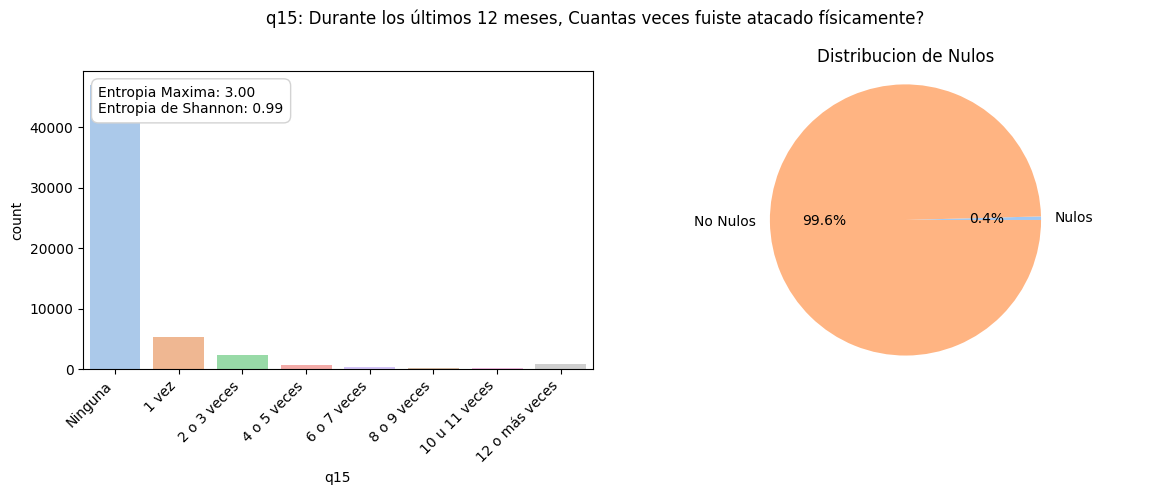

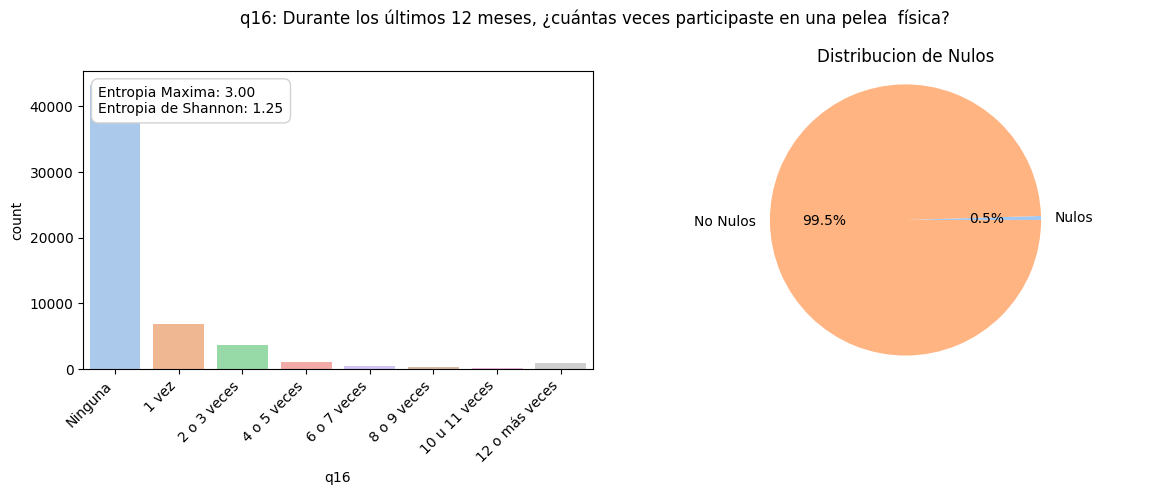

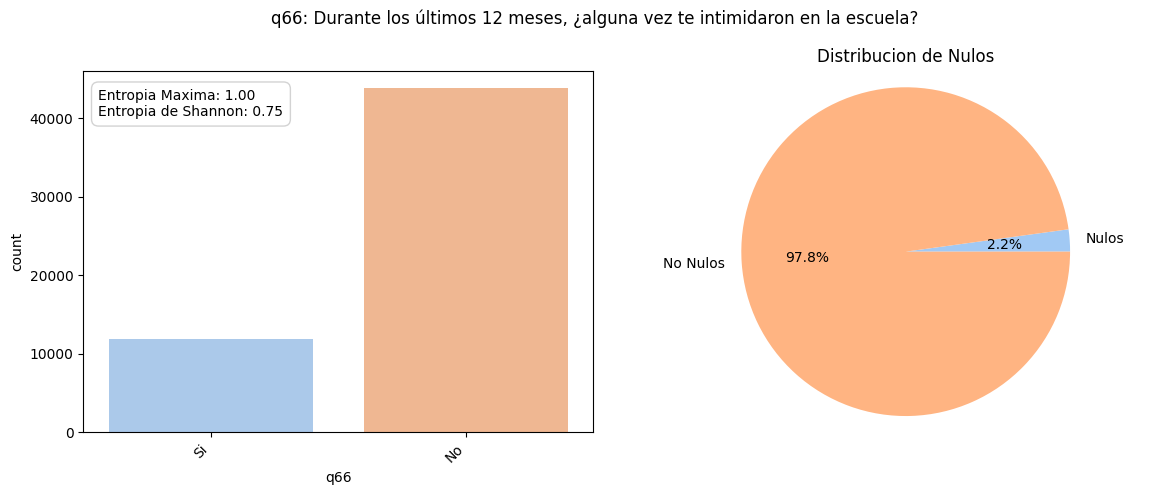

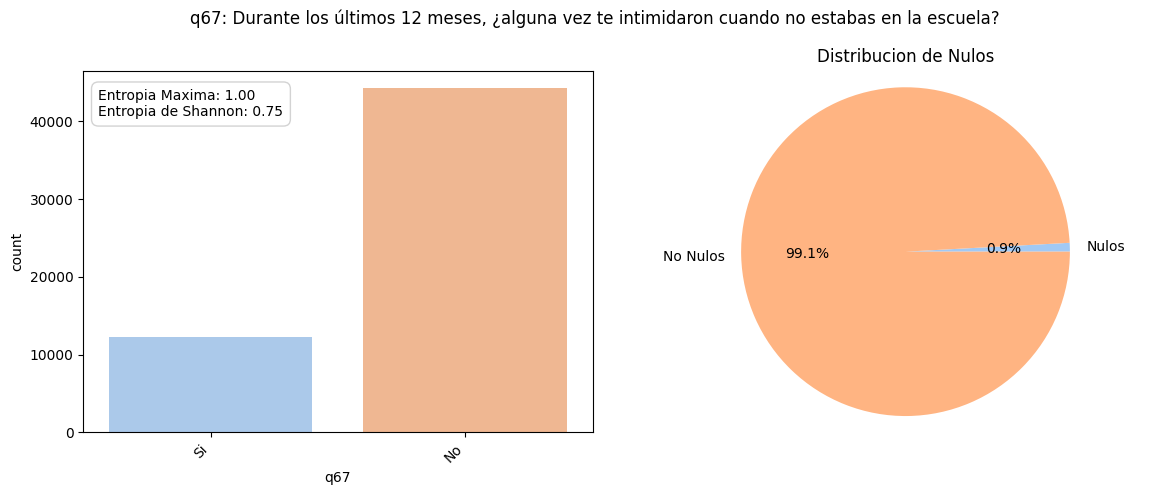

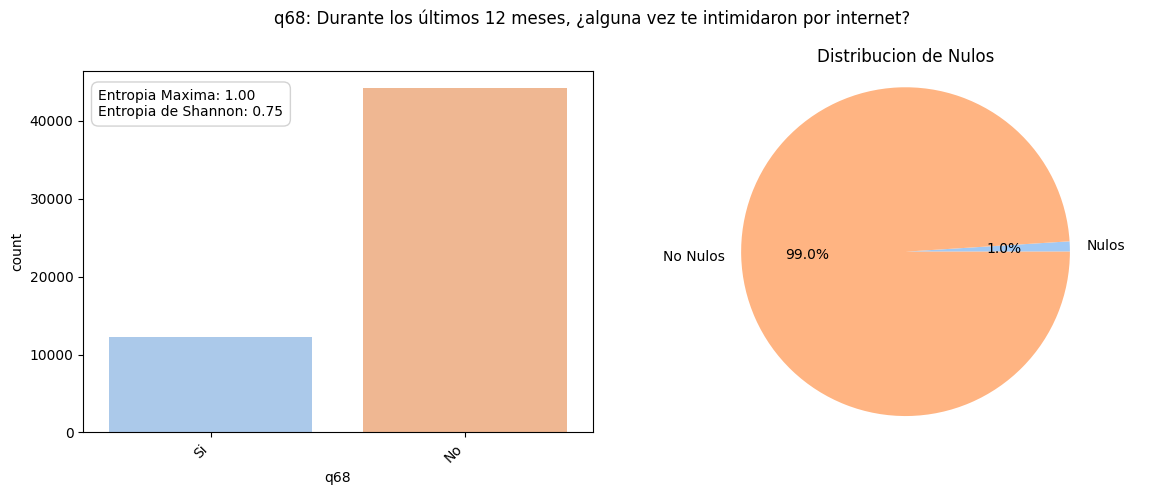

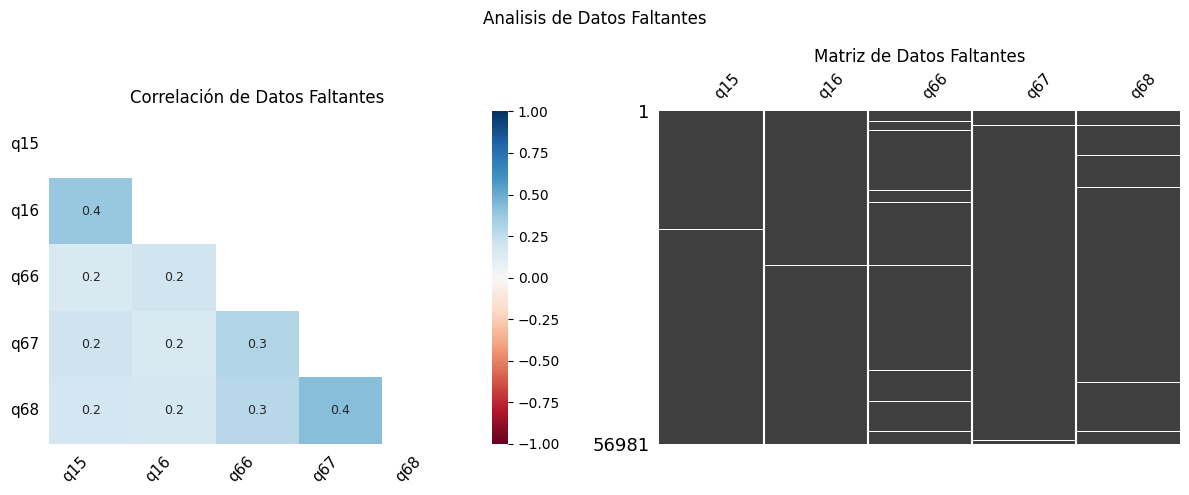

In [13]:
violencia = ["q15", "q16", "q66", "q67", "q68"]
questions_summary(violencia)

### 4.5 Apoyo Familiar

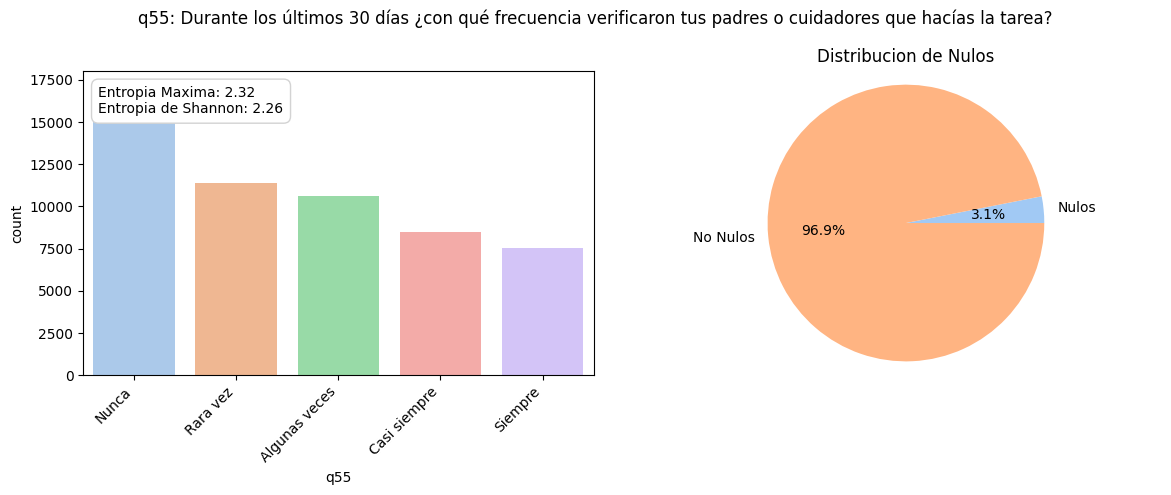

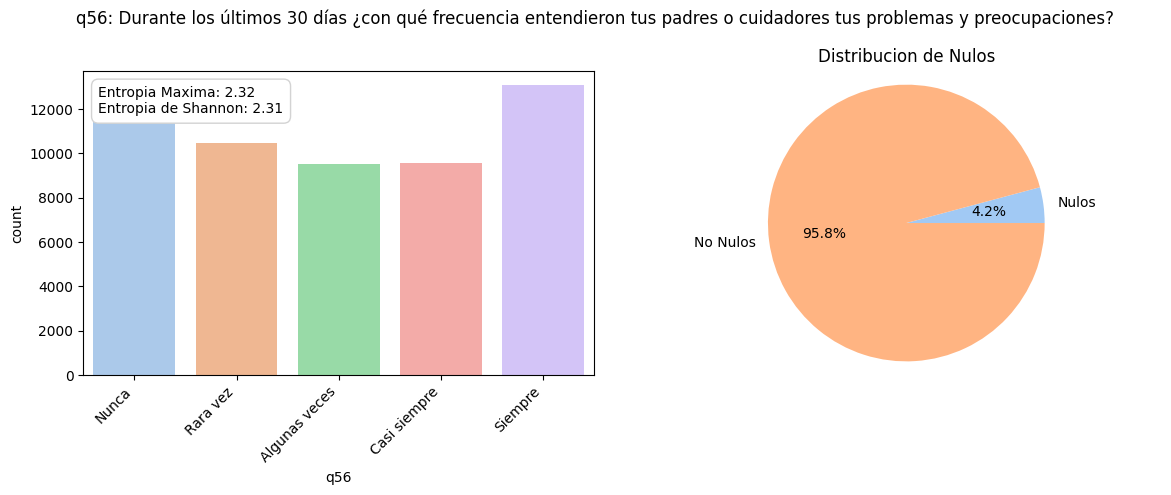

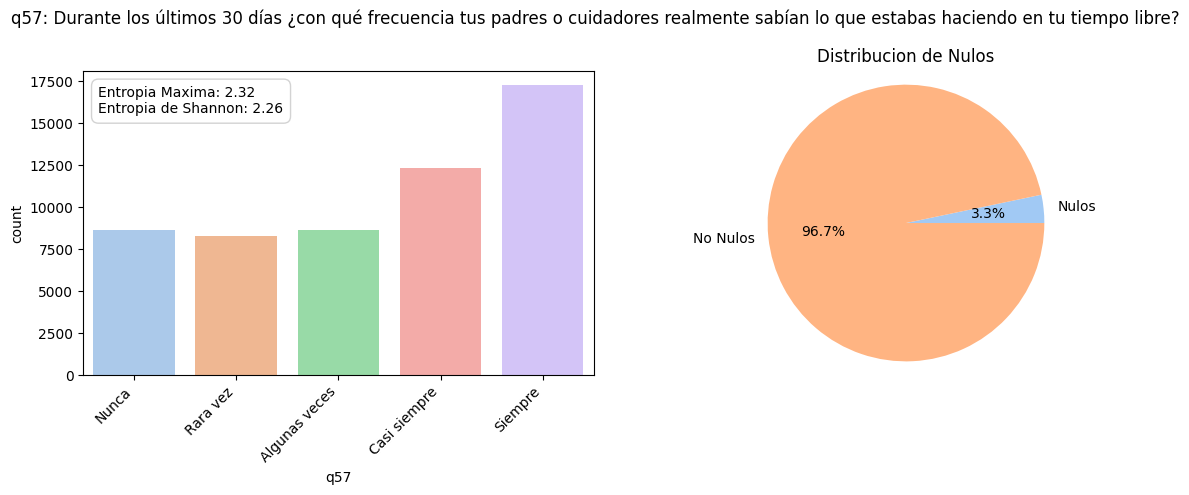

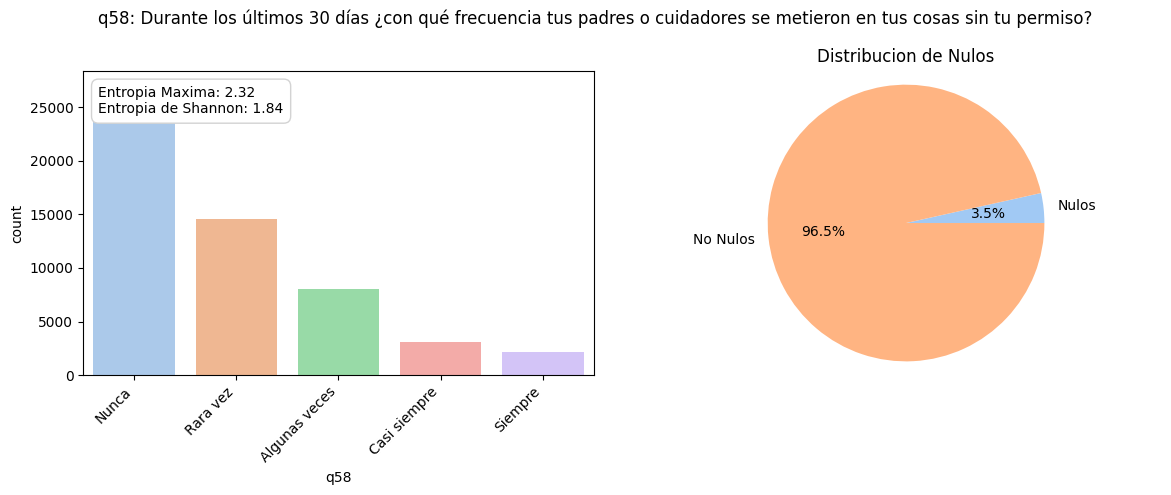

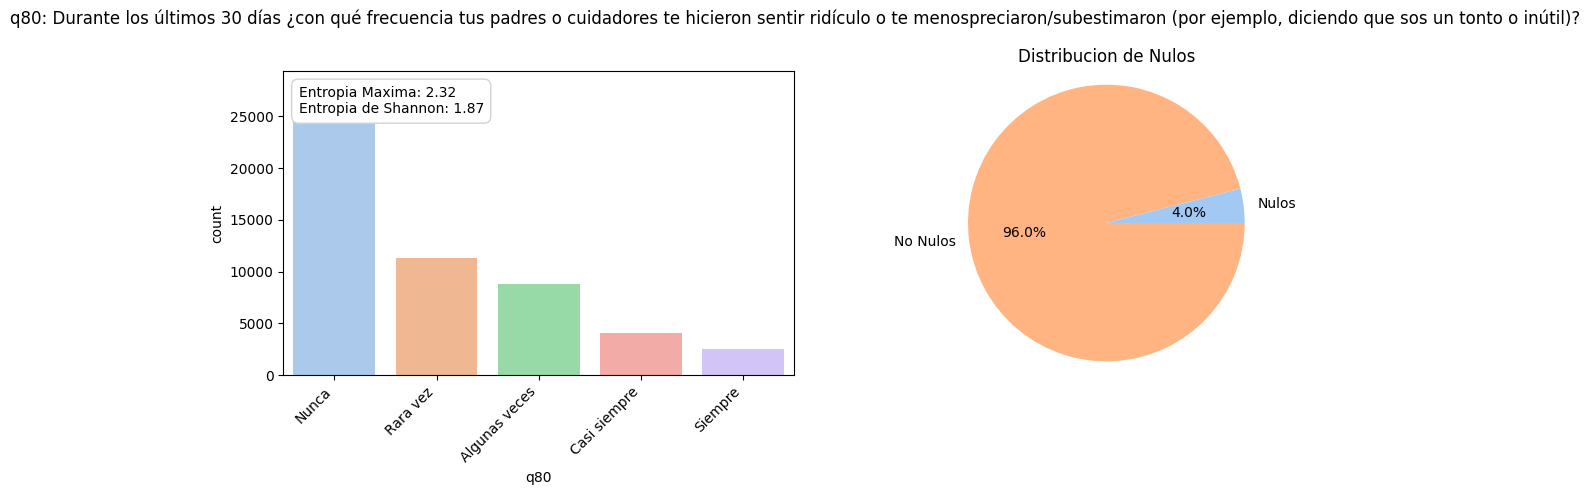

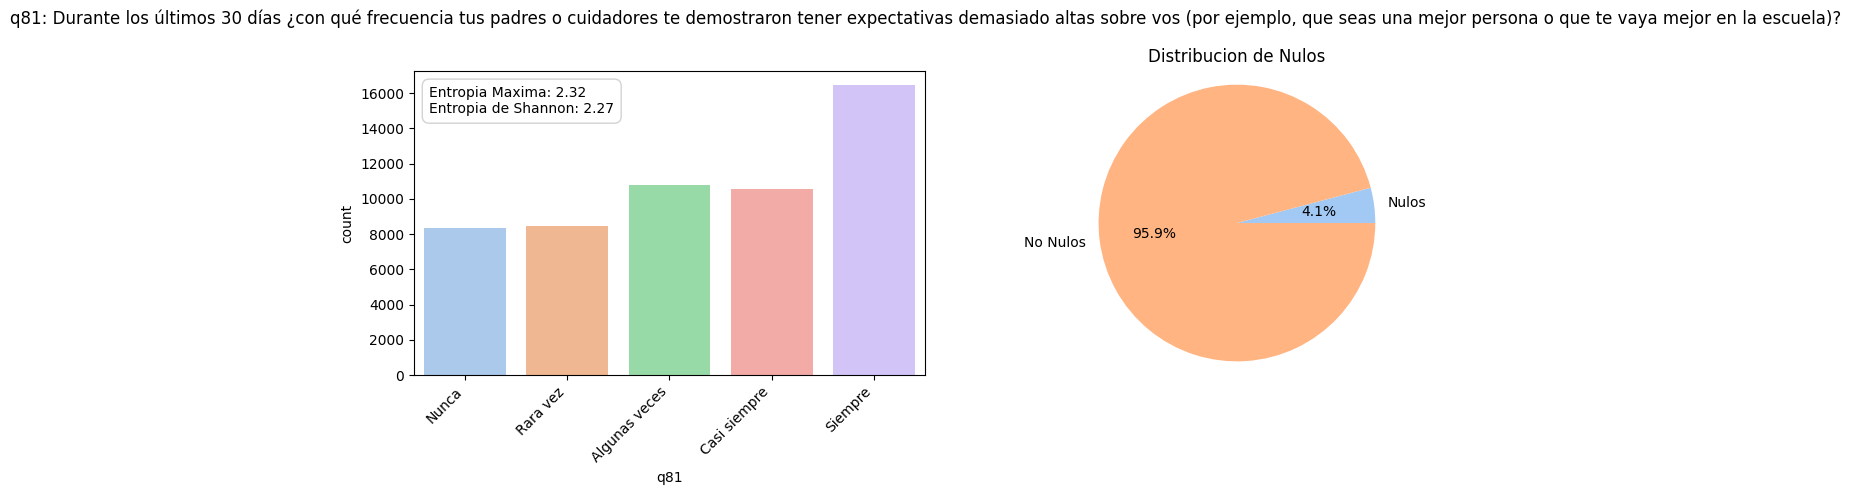

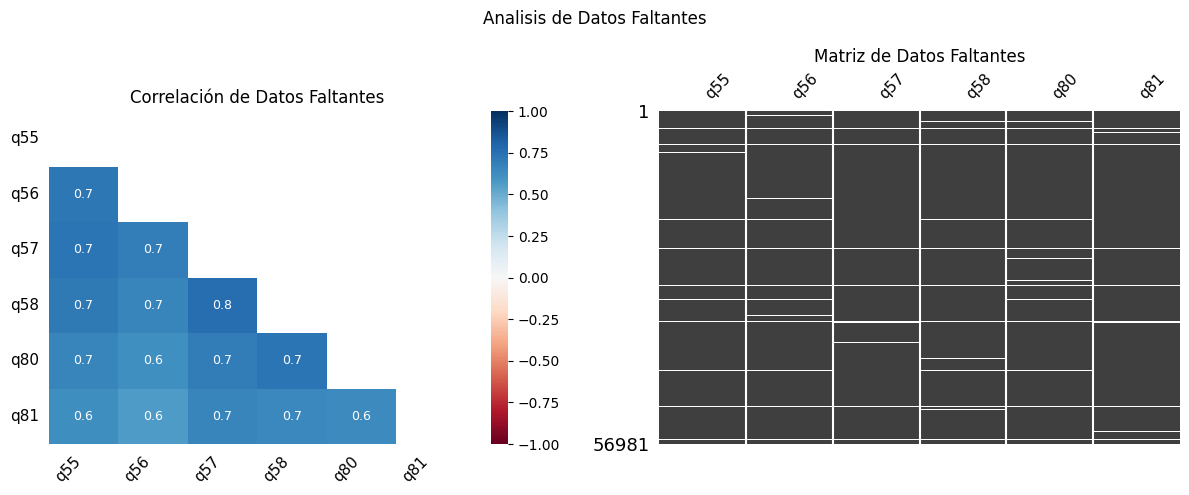

In [14]:
apoyo = ["q55", "q56", "q57", "q58", "q80", "q81"]
questions_summary(apoyo)

### 4.6 Consumo de Sustancias

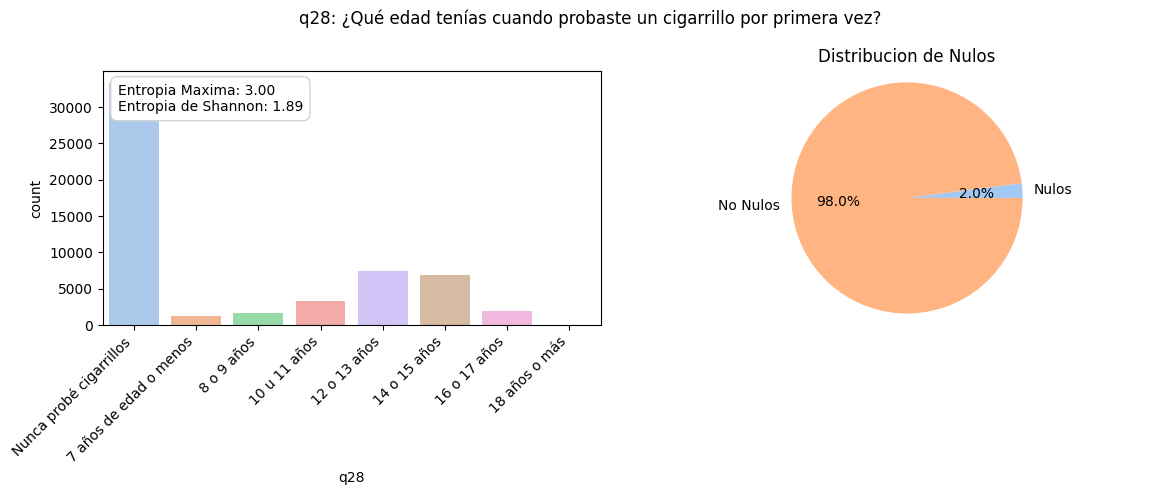

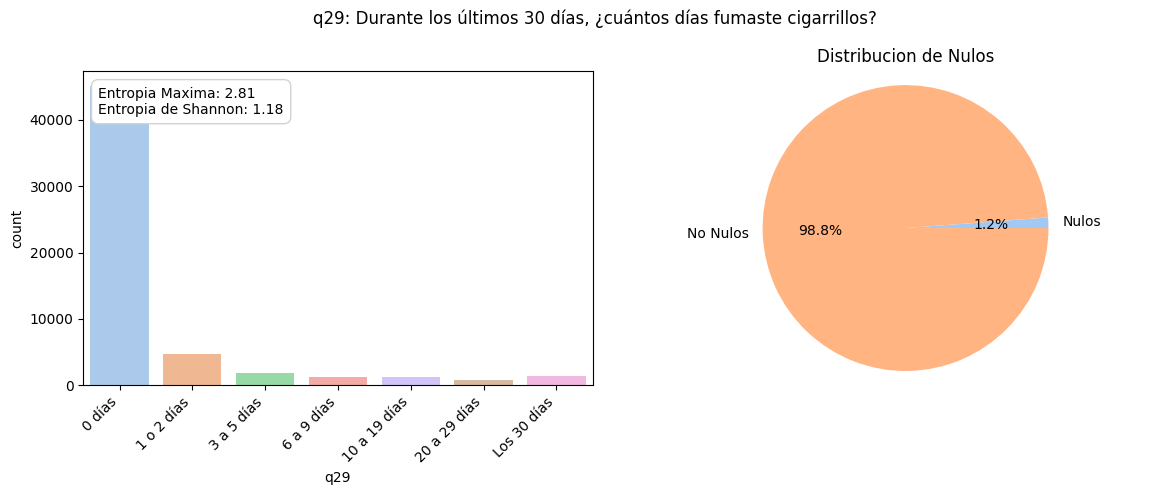

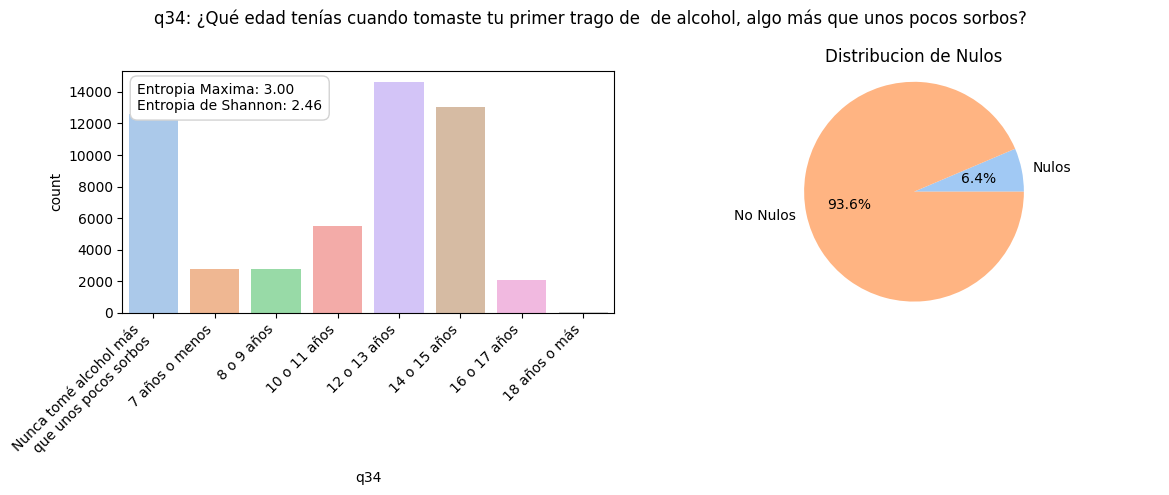

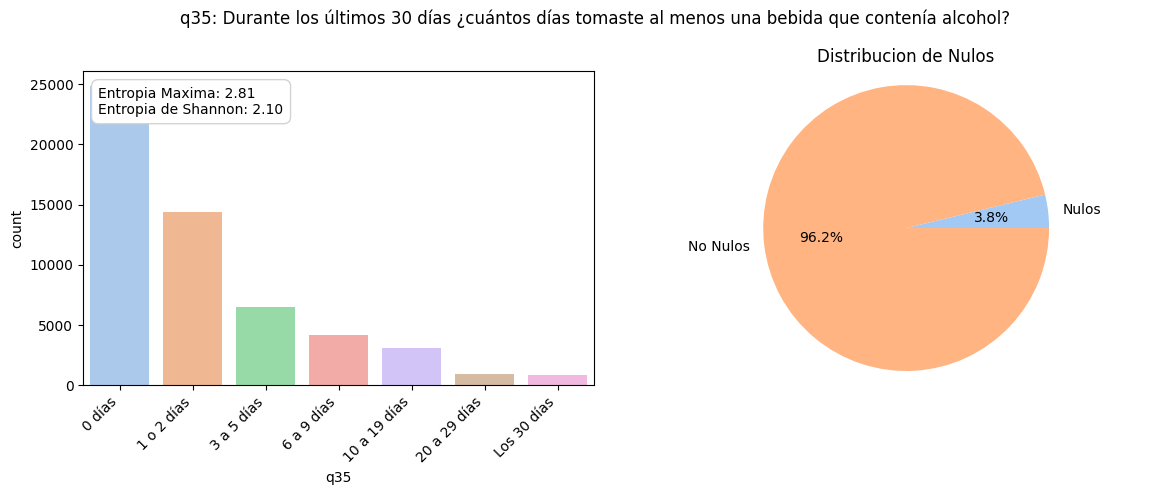

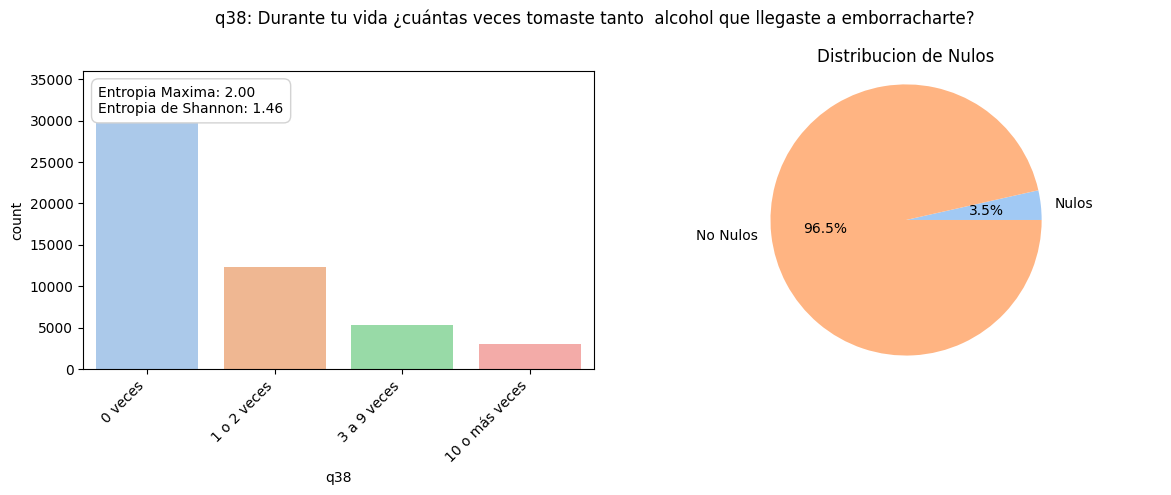

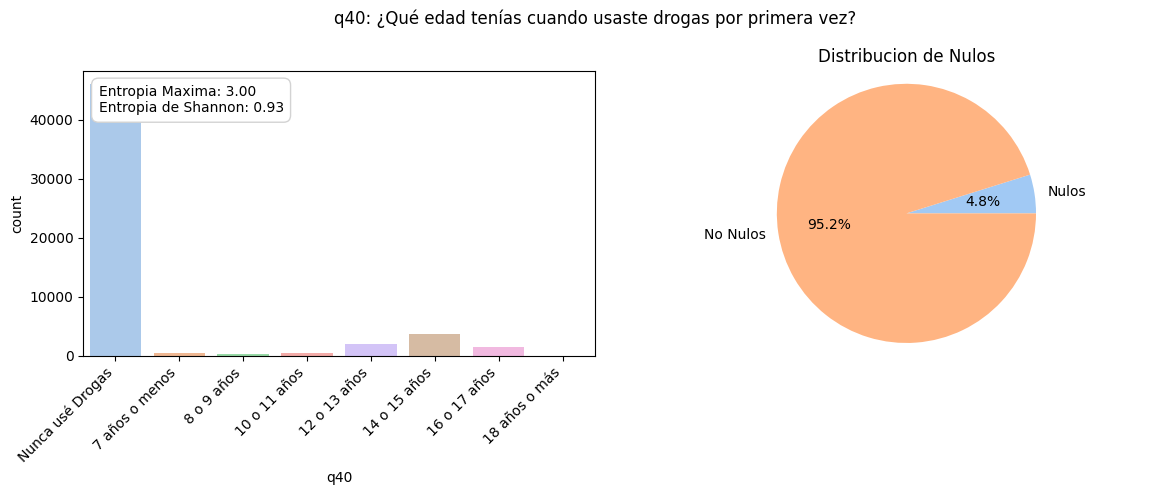

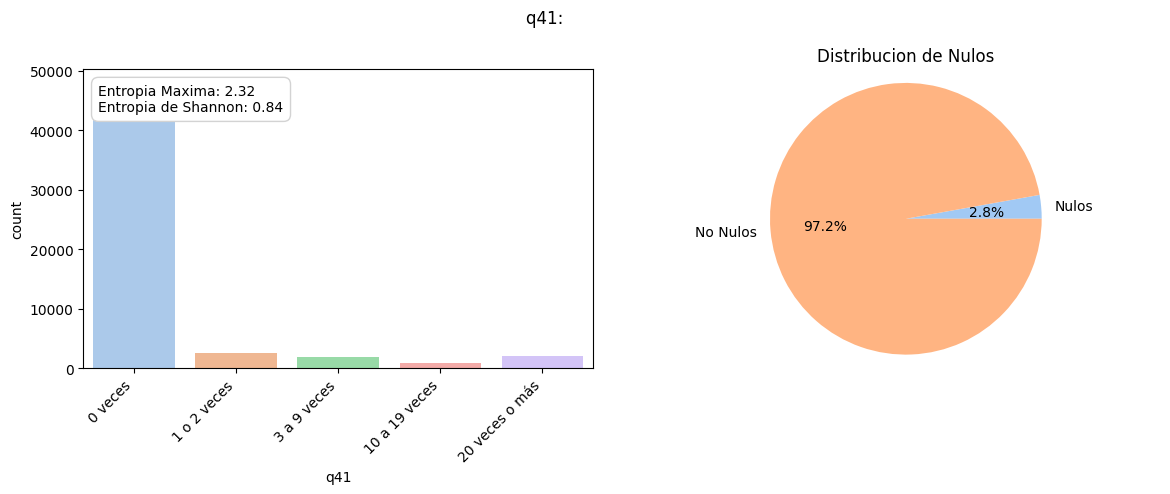

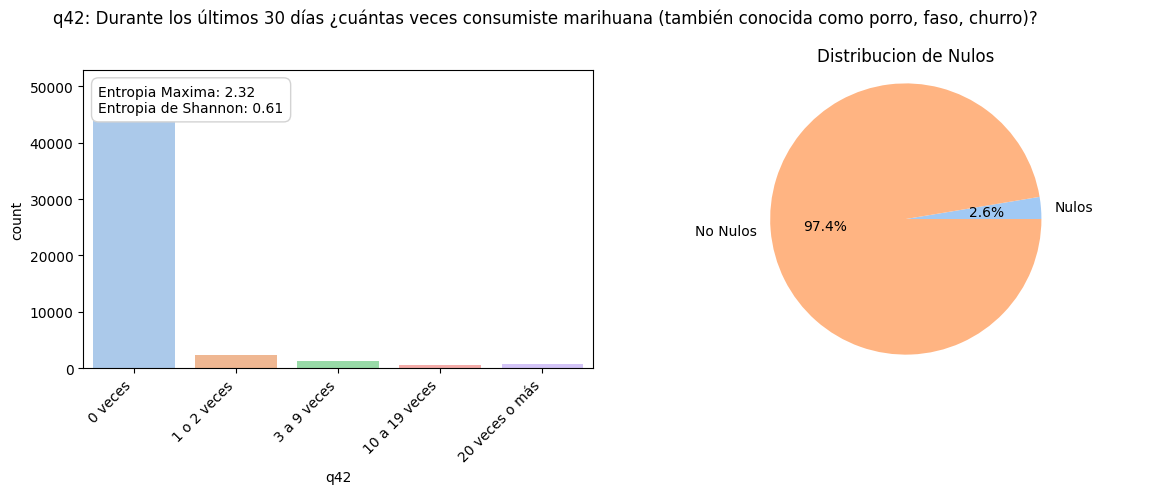

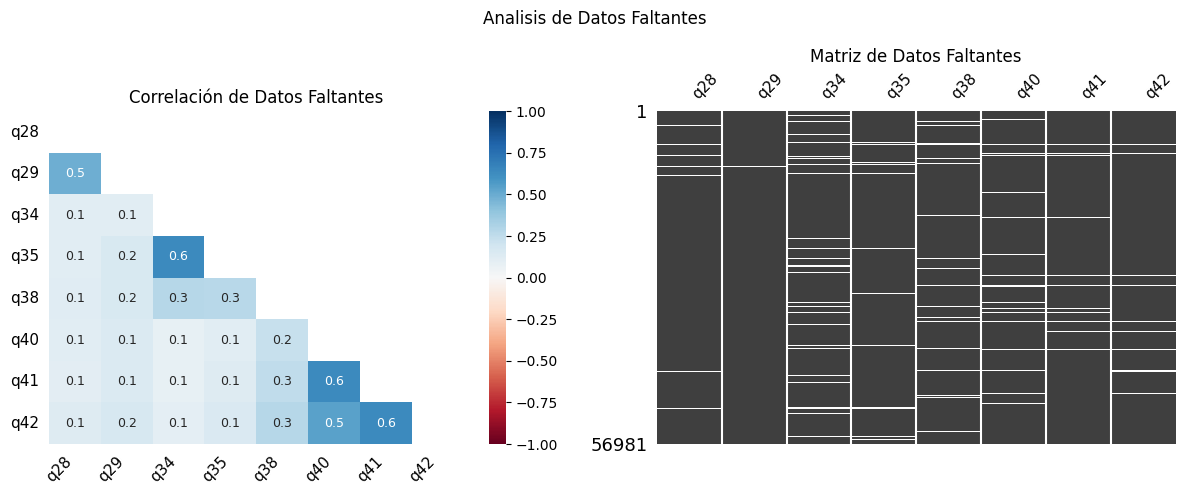

In [15]:
sustancias = ["q28", "q29", "q34", "q35", "q38", "q40", "q41", "q42"]
questions_summary(sustancias)

### 4.7 Factores Sociales y Escolares

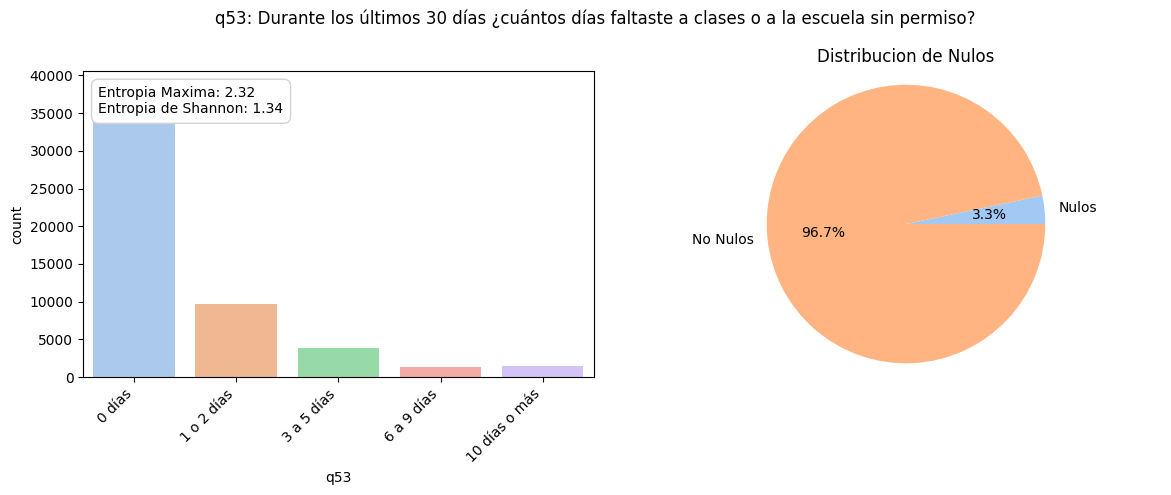

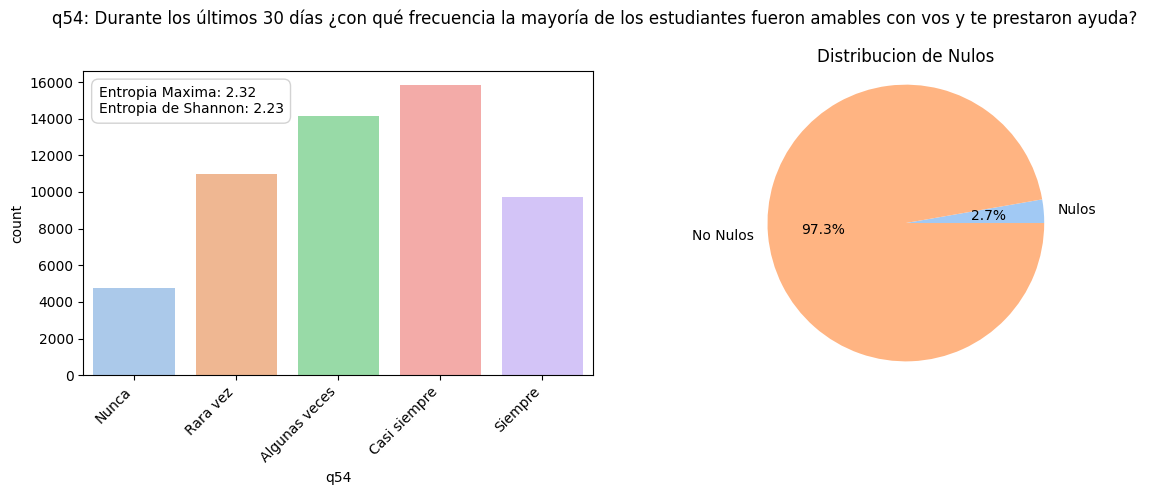

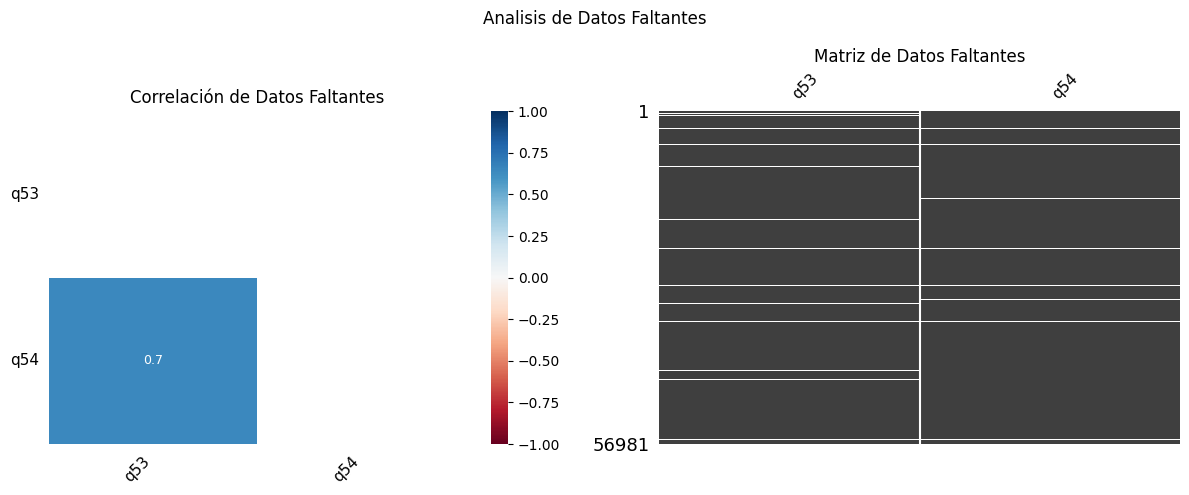

In [16]:
sociales = ["q53", "q54"]
questions_summary(sociales)

### 4.8 Factores Socioeconomicos

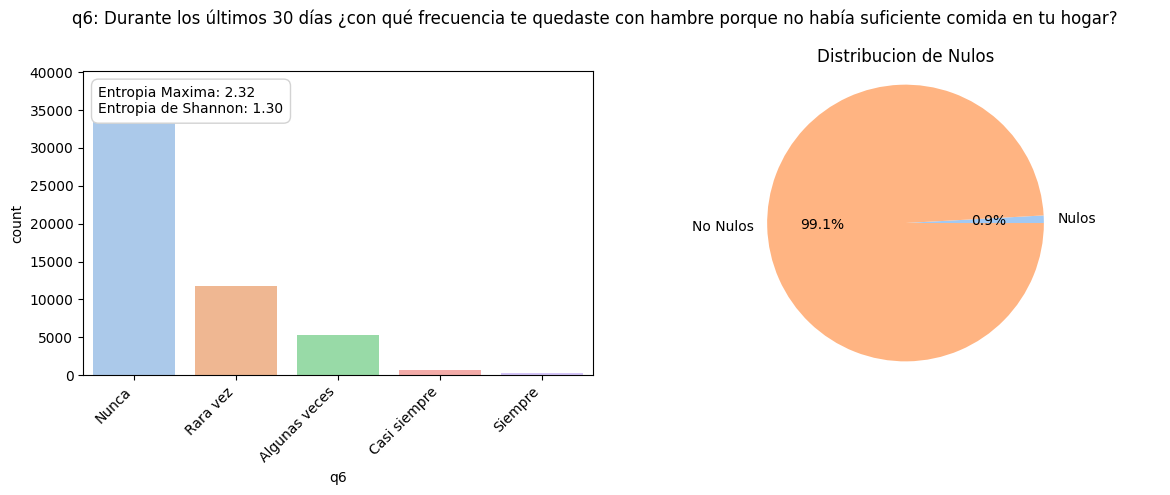

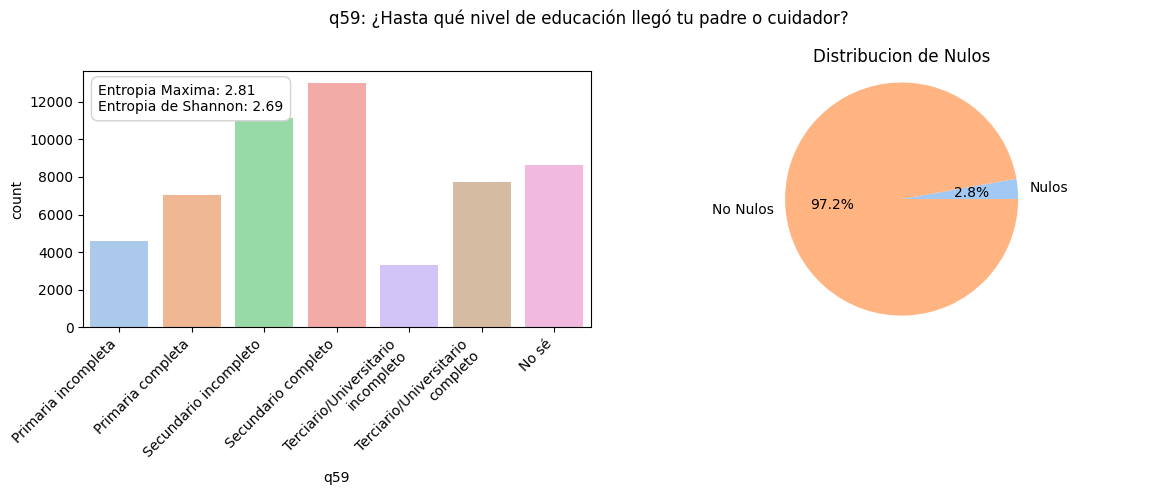

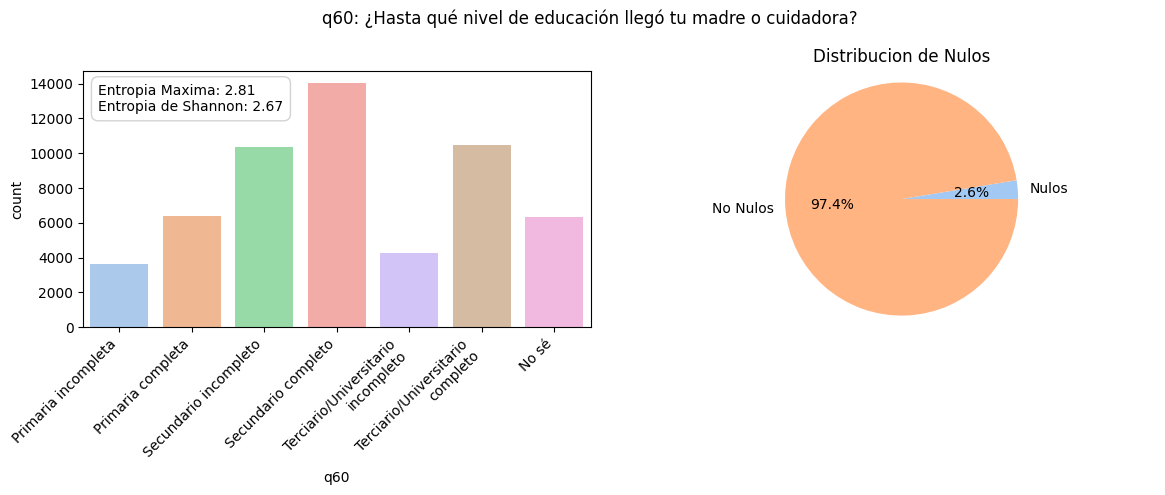

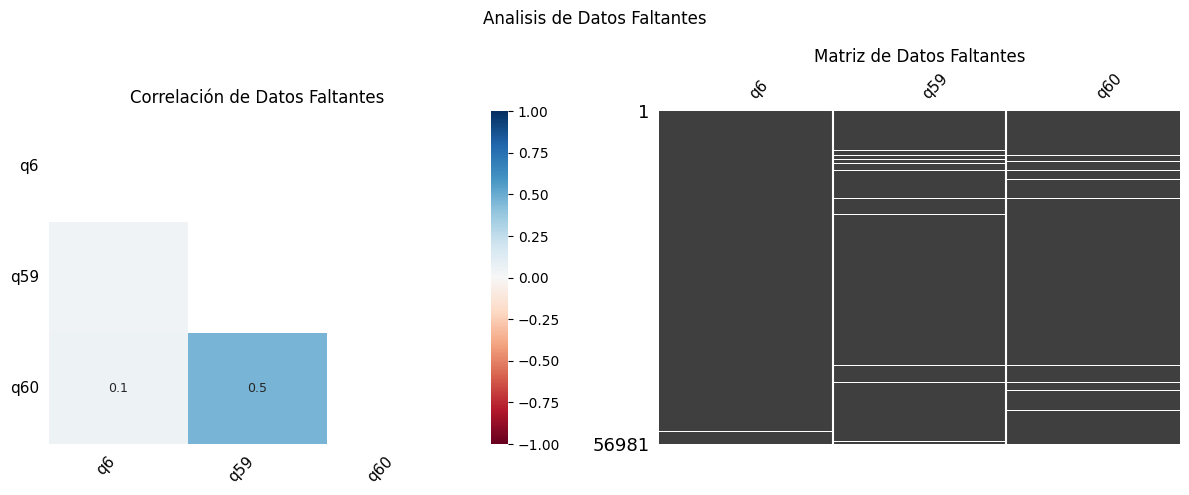

In [17]:
socioeconomicas = ["q6", "q59", "q60"]
questions_summary(socioeconomicas)

### 4.9 Conclusiones

Las features que preseleccionamos para nuestro modelo entonces, seran:

In [18]:
features = sum([demograficas, [q for q in salud_mental if q not in ["q25", "q26"]], violencia, apoyo, sustancias, sociales, socioeconomicas, [target]], []) # Usamos sum() para aplanar la lista de listas
print(features)
print(len(features), "features")

['q1', 'q2', 'q3', 'q22', 'q23', 'q24', 'q27', 'q15', 'q16', 'q66', 'q67', 'q68', 'q55', 'q56', 'q57', 'q58', 'q80', 'q81', 'q28', 'q29', 'q34', 'q35', 'q38', 'q40', 'q41', 'q42', 'q53', 'q54', 'q6', 'q59', 'q60', 'En Riesgo']
32 features


In [19]:
data = df[[q for q in features]].copy()
data.head()

,q1,q2,q3,q22,q23,q24,q27,q15,q16,q66,...,q38,q40,q41,q42,q53,q54,q6,q59,q60,En Riesgo
0,3.0,2.0,2.0,5.0,5.0,1.0,3.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,5.0,1.0,2.0,6.0,2.0,0
1,3.0,2.0,2.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0,3.0,0
2,4.0,1.0,4.0,1.0,2.0,NaN,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,3.0,1.0,4.0,4.0,0
3,6.0,1.0,2.0,1.0,3.0,2.0,4.0,1.0,3.0,2.0,...,2.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0,3.0,0
4,3.0,2.0,2.0,2.0,3.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,1.0,0


In [20]:
data.shape

(56981, 32)

## 5. Split del Dataset

Se separa el dataset en entrenamiento (*train*) y evaluacion (*test*) antes de aplicar cualquier transformacion, para evitar el *data leakage*. Las transformaciones que dependen de estadisticos (escalado, balanceo) se calculan unicamente sobre train y luego se aplican a ambos conjuntos, de manera que el test queda como una muestra no vista.

In [21]:
from sklearn.model_selection import train_test_split

Se define la matriz de features `X` y el vector target `y`, y se realiza un split 80/20 con `stratify=y`, que conserva la misma proporcion del target en train y test dado el desbalance de la clase.

Train: 45584 filas | Test: 11397 filas | 31 features


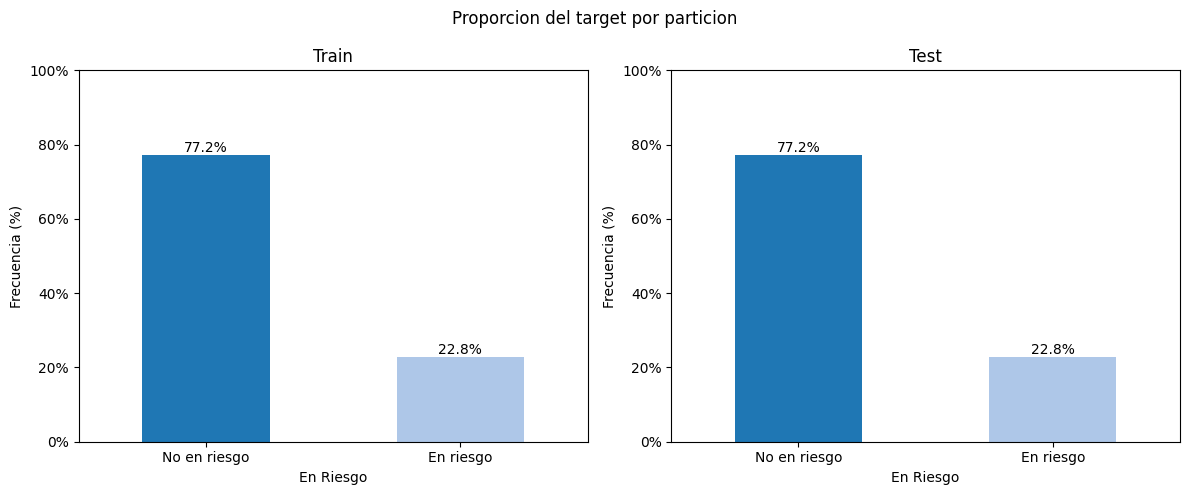

In [22]:
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas | {X_train.shape[1]} features")

# Proporcion del target en cada particion
train_pct = (y_train.value_counts(normalize=True).sort_index() * 100)
test_pct = (y_test.value_counts(normalize=True).sort_index() * 100)
etiquetas = ["No en riesgo", "En riesgo"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Proporcion del target por particion")
colors = get_colors(2)

train_pct.plot(kind="bar", ax=ax1, color=colors)
ax1.set_title("Train")
ax1.set_ylabel("Frecuencia (%)")
ax1.set_xticklabels(etiquetas, rotation=0)
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(PercentFormatter())
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.1f%%")

test_pct.plot(kind="bar", ax=ax2, color=colors)
ax2.set_title("Test")
ax2.set_ylabel("Frecuencia (%)")
ax2.set_xticklabels(etiquetas, rotation=0)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(PercentFormatter())
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## 6. Tratamiento de Nulos

Con el target ya definido (seccion 4.1) y las features preseleccionadas (seccion 5), se tratan los valores faltantes. Se analiza primero la cantidad de nulos por feature sobre el conjunto de **train**.

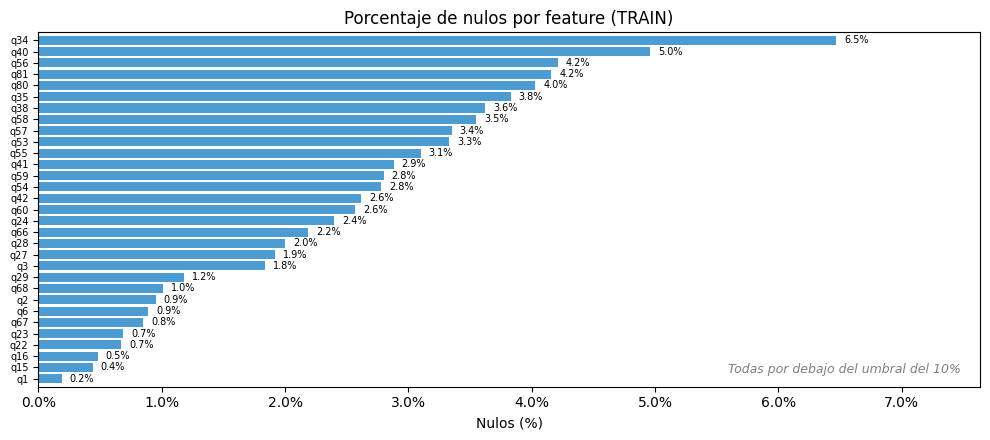

In [23]:
nulos = (X_train.isna().mean() * 100).round(2)
nulos = nulos[nulos > 0].sort_values(ascending=True)

# Porcentaje de nulos por feature. Todas estan muy por debajo del umbral del 10%.
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.barh(nulos.index, nulos.values, color="#4c9bd1")

ax.set_title("Porcentaje de nulos por feature (TRAIN)")
ax.set_xlabel("Nulos (%)")
ax.xaxis.set_major_formatter(PercentFormatter())
ax.set_xlim(0, nulos.max() * 1.18)
ax.tick_params(axis="y", labelsize=7)
ax.margins(y=0.01)

for i, v in enumerate(nulos.values):
    ax.text(v + nulos.max() * 0.01, i, f"{v:.1f}%", va="center", fontsize=7)

# El umbral del 10% queda fuera del rango: todas las features estan por debajo.
ax.text(0.98, 0.04, "Todas por debajo del umbral del 10%",
        transform=ax.transAxes, ha="right", fontsize=9,
        style="italic", color="gray")

plt.tight_layout()
plt.show()

Para detectar si los faltantes responden a un patron, se mide para cada feature **cuanto se correlacionan sus nulos con los de otra feature**. Una barra corta (cercana a 0) indica que la feature falta de forma independiente; una barra larga indica que tiende a quedar vacia junto con otra, lo que delata un patron.

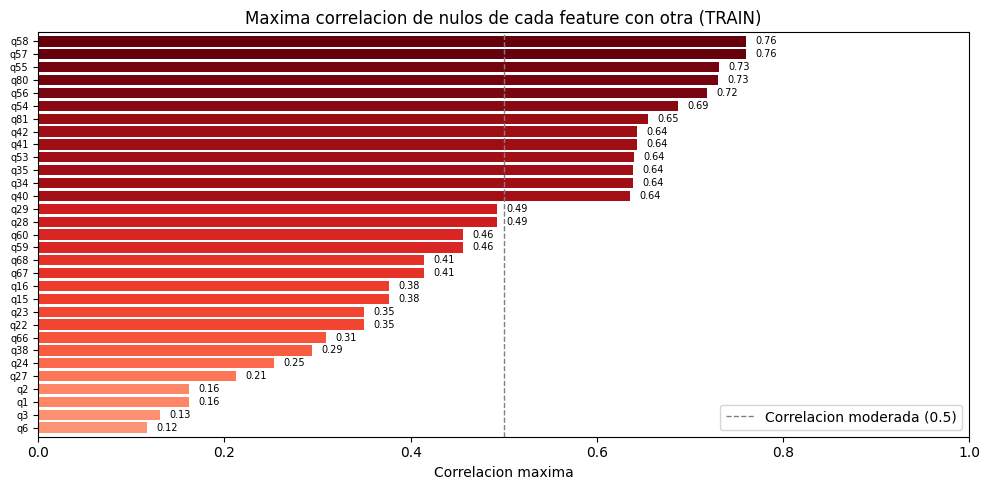

In [24]:
# Para cada feature con nulos, medimos su MAXIMA correlacion de nulo con
# CUALQUIER otra feature (excluyendo la diagonal, que siempre vale 1).
# Una barra larga indica que esa feature tiende a faltar junto con otra.
cols_con_nulos = X_train.columns[X_train.isna().any()]
corr_nulos = X_train[cols_con_nulos].isna().corr()

# Anulamos la diagonal para que no domine el maximo
np.fill_diagonal(corr_nulos.values, np.nan)
max_corr = corr_nulos.max().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Reds(0.25 + 0.75 * max_corr / max_corr.max())
ax.barh(max_corr.index, max_corr.values, color=colors)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Correlacion moderada (0.5)")
ax.set_title("Maxima correlacion de nulos de cada feature con otra (TRAIN)")
ax.set_xlabel("Correlacion maxima")
ax.set_xlim(0, 1)
ax.tick_params(axis="y", labelsize=7)
ax.margins(y=0.01)
for i, v in enumerate(max_corr.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=7)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

El heatmap revela correlaciones moderadas (hasta ~0.76) entre los nulos de un grupo concreto de features: **q54, q55, q56, q57, q58 y q80**, todas referidas al **apoyo y control parental** ("con que frecuencia tus padres o cuidadores..."). Es decir, los estudiantes que dejaron sin responder una de estas preguntas tendieron a dejar el bloque completo sin responder.

Los faltantes, entonces, no son completamente al azar (MCAR), sino que siguen un patron de **no-respuesta por bloque tematico** (mas cercano a MAR). El resto de las features no muestra correlacion apreciable entre sus nulos.

### 6.1 Eleccion de la estrategia

La estrategia de tratamiento depende de la cantidad de faltantes:

| Cantidad de faltantes | Estrategia |
|---|---|
| **Muy baja (<10%)** | Eliminar filas / Imputar |
| Baja (10-30%) | Imputar (media/mediana/moda segun distribucion) |
| Media (40-60%) | KNN / MICE / otros |
| Alta (70%+) | Eliminar columna completa |

Todas las features tienen un porcentaje de nulos **muy bajo (< 10%)**. El analisis anterior mostro que la mayoria falta de forma independiente, salvo el bloque de apoyo parental, donde la no-respuesta es por patron (MAR). En ambos casos, con un porcentaje tan bajo, las dos estrategias razonables son eliminar filas o imputar.

Aunque para <10% se acepta eliminar filas, ese umbral aplica **por columna**: como hay 31 features, los pequenos porcentajes se acumulan y eliminar toda fila con algun nulo descartaria alrededor del **30% de los registros (unos 16.700 estudiantes)**. Esa perdida es excesiva, sobre todo porque la clase de interes (estudiantes con tendencia suicida) es minoritaria y cada caso aporta senal valiosa.

Por eso se opta por **imputar**. Como las variables son categoricas, se usa la **moda** (`most_frequent`), que conserva el total de registros sin introducir valores intermedios artificiales. A diferencia de eliminar filas, la imputacion calcula un estadistico (la moda), por lo que se ajusta **solo sobre train** y se aplica a train y test, evitando el data leakage.

In [25]:
from sklearn.impute import SimpleImputer

# Imputacion por moda (most_frequent), adecuada para variables categoricas.
# El imputer se ajusta SOLO con train y se aplica a train y test, para no
# filtrar informacion del test (se evita el data leakage).
imputer = SimpleImputer(strategy="most_frequent")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Luego de imputar:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)
print()
print("Nulos restantes en train:", int(X_train.isna().sum().sum()))
print("Nulos restantes en test :", int(X_test.isna().sum().sum()))

Luego de imputar:
X_train: (45584, 31) | y_train: (45584,)
X_test : (11397, 31) | y_test : (11397,)

Nulos restantes en train: 0
Nulos restantes en test : 0


### 6.2 Dataset resultante

Queda definido el dataset: las features preseleccionadas, con los nulos imputados (conservando los 56.981 registros) y con el target ya creado.

In [26]:
total = len(X_train) + len(X_test)
print(f"Registros conservados: {total} de {len(data)} ({total / len(data) * 100:.0f}%)")
print()
X_train.head()

Registros conservados: 56981 de 56981 (100%)



,q1,q2,q3,q22,q23,q24,q27,q15,q16,q66,...,q35,q38,q40,q41,q42,q53,q54,q6,q59,q60
41546,5.0,2.0,5.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,...,5.0,4.0,6.0,5.0,5.0,3.0,4.0,1.0,4.0,3.0
43647,3.0,1.0,1.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,6.0,4.0
37666,3.0,2.0,1.0,1.0,2.0,1.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,5.0,2.0,7.0,7.0
24933,7.0,1.0,4.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1.0,4.0,4.0
37928,6.0,2.0,2.0,1.0,4.0,1.0,4.0,2.0,1.0,2.0,...,4.0,2.0,1.0,1.0,1.0,3.0,5.0,1.0,7.0,7.0


## 7. Normalizacion de Features

Las features son categoricas (binarias y ordinales) codificadas como enteros, pero estan en **escalas distintas** (p. ej. q1 -edad- va de 1 a 8, mientras que q24 -binaria- toma valores 1 o 2). Como muchos algoritmos (regresion logistica, KNN, SVM, redes neuronales) y el propio SMOTE se basan en distancias y son sensibles a la escala, se llevan todas las features a un **rango comun [0, 1]** con `MinMaxScaler`.

El scaler se ajusta (`fit`) unicamente sobre train y se aplica (`transform`) a train y test, para no filtrar informacion del test.

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit SOLO con train, transform en ambos
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

Para visualizar el efecto del escalado se compara el rango (minimo a maximo) de cada feature. **Antes**, las barras tienen largos dispares porque cada feature usa una escala propia; **despues**, todas abarcan exactamente el mismo rango [0, 1].

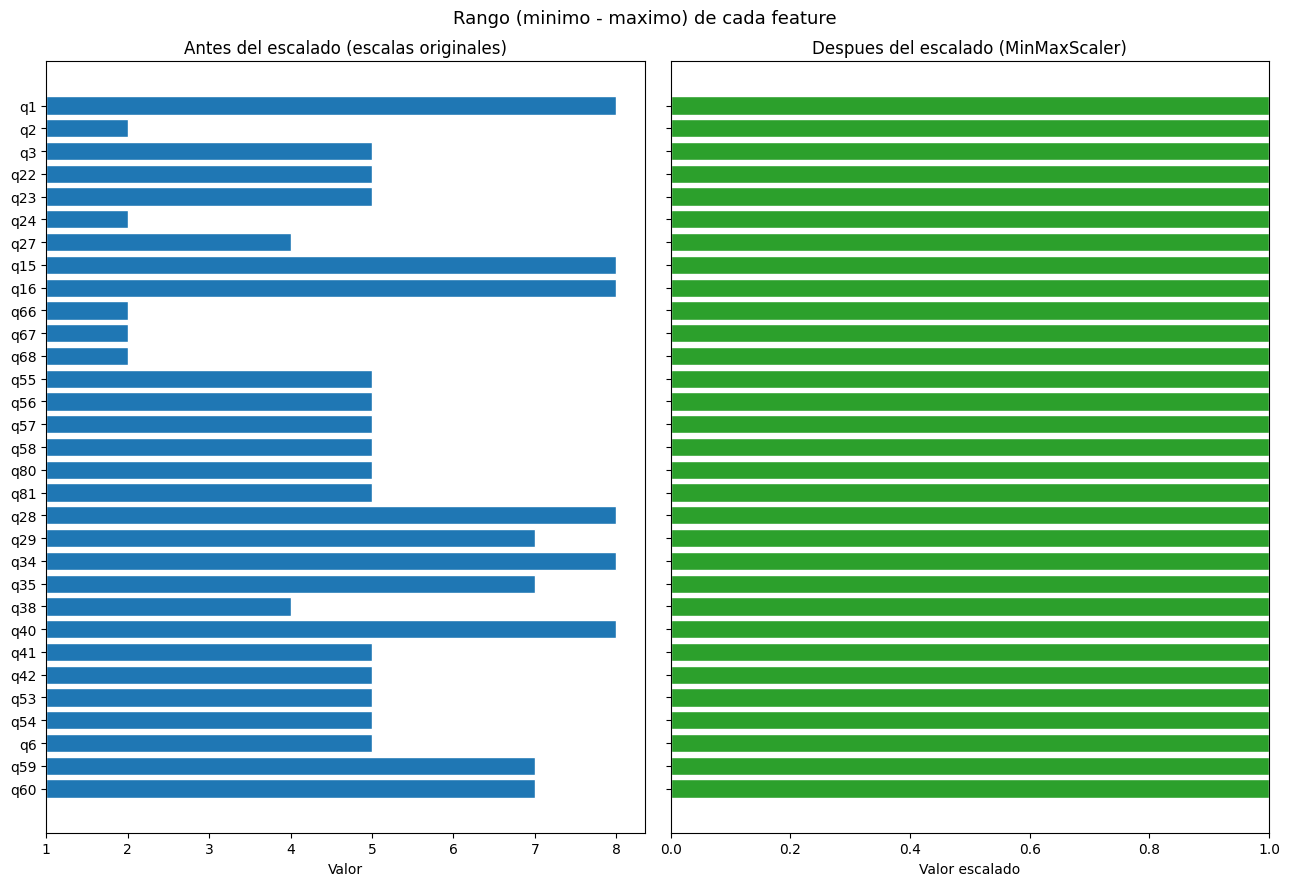

In [28]:
# Rango (minimo - maximo) de cada feature, antes y despues del escalado.
# Cada barra va del valor minimo al maximo de la feature.
feats = X_train.columns[::-1]  # invertimos para que queden en orden de arriba a abajo
y_pos = np.arange(len(feats))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 9), sharey=True)
fig.suptitle("Rango (minimo - maximo) de cada feature", fontsize=13)

# --- Antes del escalado: escalas heterogeneas ---
min_orig = X_train[feats].min()
max_orig = X_train[feats].max()
ax1.barh(y_pos, max_orig - min_orig, left=min_orig,
         color=plt.cm.tab20(0), edgecolor="white")
ax1.set_yticks(y_pos)
ax1.set_yticklabels(feats)
ax1.set_title("Antes del escalado (escalas originales)")
ax1.set_xlabel("Valor")

# --- Despues del escalado: todas en [0, 1] ---
min_sc = X_train_scaled[feats].min()
max_sc = X_train_scaled[feats].max()
ax2.barh(y_pos, max_sc - min_sc, left=min_sc,
         color=plt.cm.tab20(4), edgecolor="white")
ax2.set_title("Despues del escalado (MinMaxScaler)")
ax2.set_xlabel("Valor escalado")
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [29]:
X_train_scaled.head()

,q1,q2,q3,q22,q23,q24,q27,q15,q16,q66,...,q35,q38,q40,q41,q42,q53,q54,q6,q59,q60
41546,0.571429,1.0,1.00,0.25,0.00,1.0,0.333333,0.000000,0.0,1.0,...,0.666667,1.000000,0.714286,1.0,1.0,0.5,0.75,0.00,0.500000,0.333333
43647,0.285714,0.0,0.00,0.00,0.00,1.0,1.000000,0.000000,0.0,1.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.50,0.00,0.833333,0.500000
37666,0.285714,1.0,0.00,0.00,0.25,0.0,1.000000,0.000000,0.0,1.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.00,0.25,1.000000,1.000000
24933,0.857143,0.0,0.75,0.00,0.00,1.0,1.000000,0.000000,0.0,1.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.75,0.00,0.500000,0.500000
37928,0.714286,1.0,0.25,0.00,0.75,0.0,1.000000,0.142857,0.0,1.0,...,0.500000,0.333333,0.000000,0.0,0.0,0.5,1.00,0.00,1.000000,1.000000


## 8. Tratamiento del Desbalance

Se analiza la distribucion del target en el conjunto de **train**.

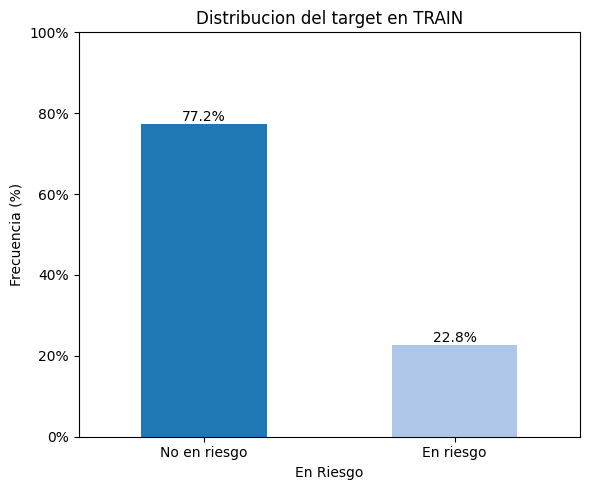

In [30]:
proporcion = (y_train.value_counts(normalize=True).sort_index() * 100)

fig, ax = plt.subplots(figsize=(6, 5))
colors = get_colors(2)
proporcion.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Distribucion del target en TRAIN")
ax.set_ylabel("Frecuencia (%)")
ax.set_xticklabels(["No en riesgo", "En riesgo"], rotation=0)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()

El target esta **desbalanceado**: cerca del **79%** de los estudiantes corresponde a la clase "No en riesgo" y solo el **21%** a "En riesgo". Sin tratamiento, un modelo tenderia a la clase mayoritaria (prediciendo casi siempre "No en riesgo" con accuracy alta), lo opuesto al objetivo de **detectar** a los estudiantes en riesgo.

### 8.1 Balanceo del target con SMOTE

El balanceo se realiza **en funcion del target** y solo sobre **train**: el test debe conservar la distribucion real para que la evaluacion sea representativa.

Se aplica **SMOTE** (*Synthetic Minority Over-sampling Technique*), que genera ejemplos sinteticos de la clase minoritaria interpolando entre vecinos cercanos en lugar de duplicar filas. Por eso el escalado se aplica antes: SMOTE se basa en distancias.

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("ANTES del balanceo (train):")
print((y_train.value_counts().sort_index()).to_string())
print()
print("DESPUES del balanceo (train):")
print((y_train_bal.value_counts().sort_index()).to_string())
print()
print("X_train_bal:", X_train_bal.shape, "| X_test_scaled (sin balancear):", X_test_scaled.shape)

ANTES del balanceo (train):
En Riesgo
0    35196
1    10388

DESPUES del balanceo (train):
En Riesgo
0    35196
1    35196

X_train_bal: (70392, 31) | X_test_scaled (sin balancear): (11397, 31)


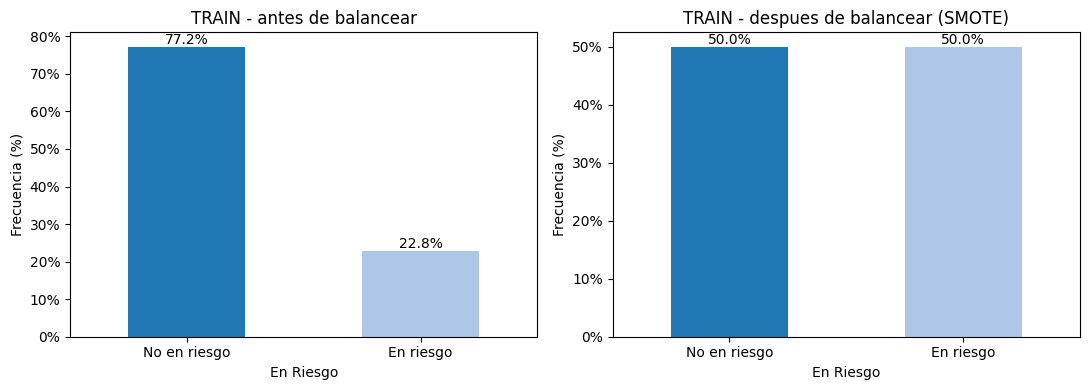

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = get_colors(2)

(y_train.value_counts(normalize=True).sort_index() * 100).plot(
    kind="bar", ax=axes[0], color=colors)
axes[0].set_title("TRAIN - antes de balancear")
axes[0].set_ylabel("Frecuencia (%)")
axes[0].set_xticklabels(["No en riesgo", "En riesgo"], rotation=0)
axes[0].yaxis.set_major_formatter(PercentFormatter())

(y_train_bal.value_counts(normalize=True).sort_index() * 100).plot(
    kind="bar", ax=axes[1], color=colors)
axes[1].set_title("TRAIN - despues de balancear (SMOTE)")
axes[1].set_ylabel("Frecuencia (%)")
axes[1].set_xticklabels(["No en riesgo", "En riesgo"], rotation=0)
axes[1].yaxis.set_major_formatter(PercentFormatter())

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### 8.2 Consideraciones sobre el desbalanceo

El balanceo se aplica unicamente sobre el **target**, ya que es la variable que el modelo debe predecir. Mas alla del target, varias features presentan categorias poco representadas (respuestas extremas en consumo de sustancias o frecuencias altas de violencia), lo que constituye un desbalanceo a nivel de los predictores. Este no se trata de forma directa: refleja la prevalencia real de cada conducta en la poblacion y forma parte de la senal que el modelo debe aprender, por lo que alterarlo distorsionaria las relaciones entre variables.

Con esto, los conjuntos quedan listos para el modelado:

- **`X_train_bal`, `y_train_bal`** -> entrenamiento (escalado y balanceado).
- **`X_test_scaled`, `y_test`** -> evaluacion (escalado, sin balancear).

## 9. Reduccion de Dimensionalidad

### 9.1 Analizamos el poder predictivo entre las variables y la target categórica con Chi2

In [33]:
selector_chi2 = SelectKBest(score_func=chi2, k='all')
selector_chi2.fit(X_train_bal, y_train_bal)

variables = [f for f in features if f != target]

chi2_scores = pd.Series(selector_chi2.scores_, index=variables, name='chi2')
chi2_pvals  = pd.Series(selector_chi2.pvalues_, index=variables, name='chi2_pval')
chi2_result = pd.DataFrame({
    'score': chi2_scores,
    'p_value': chi2_pvals
}).sort_values('score', ascending=False)

display(chi2_result.style.format({'score': '{:.2f}', 'p_value': '{:.3f}'}))

,score,p_value
q24,10074.92,0.000
q22,2419.54,0.000
q80,2180.19,0.000
q23,1459.83,0.000
q56,1146.39,0.000
q29,951.30,0.000
q68,877.57,0.000
q2,865.56,0.000
q15,833.02,0.000
q57,686.47,0.000


Se observa que q24 tiene una relacion muy fuerte con la variable target respecto de las demas preguntas del cuestionario. Esto tiene sentido dado el contenido de la pregunta:

In [34]:
traducciones["q24"]

'Durante los últimos 12 meses, ¿alguna vez consideraste seriamente la posibilidad de intentar suicidarte?'

Por esta razon se descarta este feature. En una futura iteracion podriamos incorporar esta pregunta a la derivacion de nuestra variable target.

In [35]:
chi2_result = chi2_result.drop("q24")

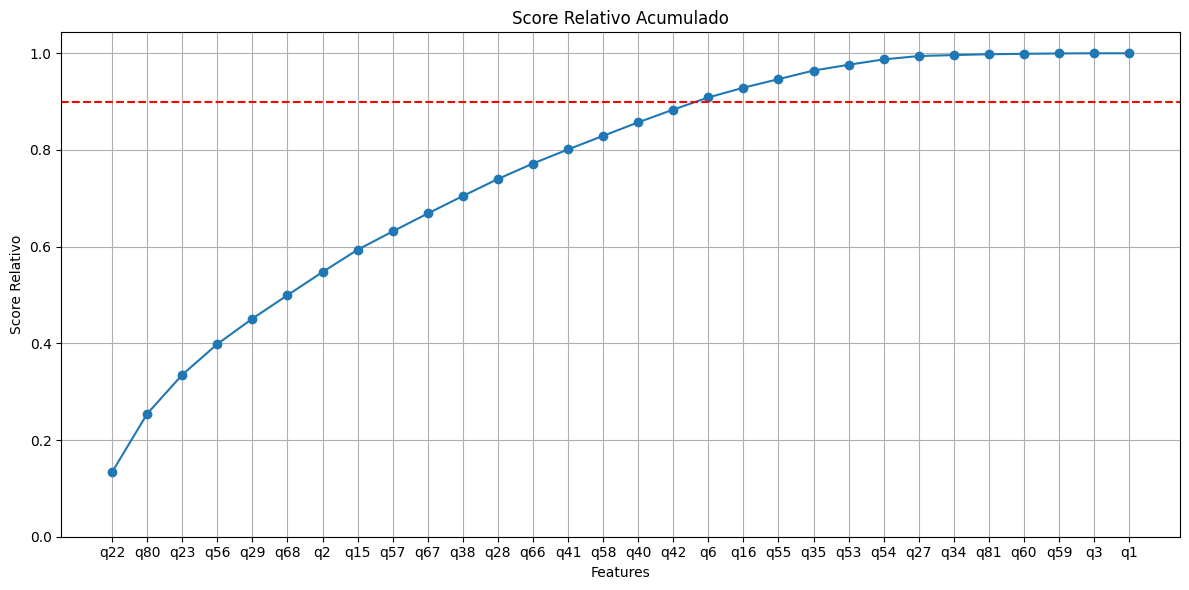

In [36]:
relative_scores = (chi2_result["score"] / np.sum(chi2_result["score"]))

cumulative_score = np.cumsum(relative_scores)

x_range = range(len(cumulative_score))

plt.figure(figsize=(12, 6))
plt.plot(x_range, cumulative_score, marker='o')
plt.xticks(x_range, labels=cumulative_score.index)
plt.xlabel('Features')
plt.ylabel('Score Relativo')
plt.ylim(bottom=0)
plt.title('Score Relativo Acumulado')
plt.grid(True)
plt.axhline(y=0.9, color='red', linestyle='--', label='90%')
plt.tight_layout()
plt.show()

Nos vamos a quedar entonces con las features hasta **q6**.

In [37]:
seleccionadas = chi2_result.index[:19]
seleccionadas

Index(['q22', 'q80', 'q23', 'q56', 'q29', 'q68', 'q2', 'q15', 'q57', 'q67',
       'q38', 'q28', 'q66', 'q41', 'q58', 'q40', 'q42', 'q6', 'q16'],
      dtype='object')

In [38]:
X_train_red, y_train_red = X_train_bal[seleccionadas], y_train_bal
X_test_red, y_test_red = X_test_scaled[seleccionadas], y_test

X_train_red.head()

,q22,q80,q23,q56,q29,q68,q2,q15,q57,q67,q38,q28,q66,q41,q58,q40,q42,q6,q16
0,0.25,0.50,0.00,0.75,0.833333,0.0,1.0,0.000000,0.25,1.0,1.000000,0.571429,1.0,1.0,0.25,0.714286,1.0,0.00,0.0
1,0.00,0.00,0.00,0.00,0.000000,1.0,0.0,0.000000,1.00,1.0,0.000000,0.000000,1.0,0.0,0.00,0.000000,0.0,0.00,0.0
2,0.00,0.00,0.25,1.00,0.000000,0.0,1.0,0.000000,1.00,1.0,0.000000,0.000000,1.0,0.0,0.00,0.000000,0.0,0.25,0.0
3,0.00,0.00,0.00,1.00,0.000000,1.0,0.0,0.000000,1.00,1.0,0.000000,0.000000,1.0,0.0,0.25,0.000000,0.0,0.00,0.0
4,0.00,0.75,0.75,0.50,0.333333,0.0,1.0,0.142857,0.75,1.0,0.333333,0.571429,1.0,0.0,0.25,0.000000,0.0,0.00,0.0


### 9.2 Análisis de Componentes Principales (PCA)

In [39]:
components = len(X_train_red.columns)
component_range = range(1, components + 1)
component_names = [f"PC{n}" for n in component_range]

pca = PCA(n_components=components)
pca.fit(X_train_red)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=component_names,
    index=X_train_red.columns
)

loadings_desc = loadings.copy()
loadings_desc.index = loadings_desc.index.map(traducciones)

loadings_desc

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
"Durante los últimos 12 meses, ¿con qué frecuencia te sentiste solo o sola?",0.278960,-0.074893,0.134191,-0.086626,0.053627,0.077747,0.361790,-0.475506,0.262368,0.055066,-0.123642,-0.100596,-0.636371,0.099217,-0.098276,0.047173,-0.033770,-0.004907,0.002705
"Durante los últimos 30 días ¿con qué frecuencia tus padres o cuidadores te hicieron sentir ridículo o te menospreciaron/subestimaron (por ejemplo, diciendo que sos un tonto o inútil)?",0.246304,0.001740,0.159582,-0.213198,0.024894,0.047832,0.438367,0.289045,-0.069199,0.038481,0.073975,0.743061,0.040608,-0.139835,-0.050803,-0.026857,-0.035015,-0.013276,0.001600
Durante los últimos 12 meses ¿con qué frecuencia estuviste tan preocupado por algo que no podías dormir por la noche?,0.227412,-0.046849,0.084612,-0.017384,0.014984,0.071491,0.303278,-0.328797,0.360034,0.034022,0.050968,-0.221105,0.685742,-0.279161,-0.017556,-0.049315,-0.004811,-0.001233,0.001548
Durante los últimos 30 días ¿con qué frecuencia entendieron tus padres o cuidadores tus problemas y preocupaciones?,-0.237745,-0.101866,-0.371526,0.483541,0.070347,0.060856,0.105417,0.235477,0.655429,-0.026240,-0.033112,0.200629,-0.107255,-0.048417,0.016613,-0.009613,0.002580,-0.013472,-0.003820
"Durante los últimos 30 días, ¿cuántos días fumaste cigarrillos?",0.109956,0.135741,0.173299,0.234041,0.084403,0.031611,-0.039113,0.050568,0.001903,-0.018079,-0.090317,0.010001,0.103781,0.384703,-0.571410,-0.587410,0.094869,-0.154661,-0.025128
"Durante los últimos 12 meses, ¿alguna vez te intimidaron por internet?",-0.440128,-0.031569,0.284367,-0.164682,0.744967,-0.346088,0.118924,-0.022919,0.068526,-0.041402,0.020373,-0.018929,0.022288,0.005511,0.006069,0.008695,0.007469,-0.002589,0.000044
¿Cuál es tu sexo?,0.314568,-0.856955,0.188102,0.181098,0.109651,-0.107243,-0.213981,0.122284,-0.043363,0.042284,0.009637,-0.001449,0.034641,0.074217,0.019058,0.055663,-0.015868,-0.006054,-0.003034
"Durante los últimos 12 meses, Cuantas veces fuiste atacado físicamente?",0.072515,0.059026,-0.001055,-0.014638,0.014073,0.008376,0.064637,0.013996,0.072634,0.040149,0.020818,0.051376,0.130115,0.402796,-0.020594,0.408210,0.778237,0.156644,0.003988
Durante los últimos 30 días ¿con qué frecuencia tus padres o cuidadores realmente sabían lo que estabas haciendo en tu tiempo libre?,-0.191748,-0.179403,-0.336343,0.390554,0.093213,0.083132,0.507381,-0.240467,-0.562842,0.030333,0.042235,-0.011111,0.077288,0.092831,0.005792,-0.002397,-0.012440,0.006821,0.008897
"Durante los últimos 12 meses, ¿alguna vez te intimidaron cuando no estabas en la escuela?",-0.424438,-0.188315,0.365705,-0.083688,-0.043971,0.798792,-0.027094,-0.001176,0.022993,0.010665,0.006587,0.013035,0.016165,0.034354,0.003690,0.015632,0.016651,-0.008690,0.000405


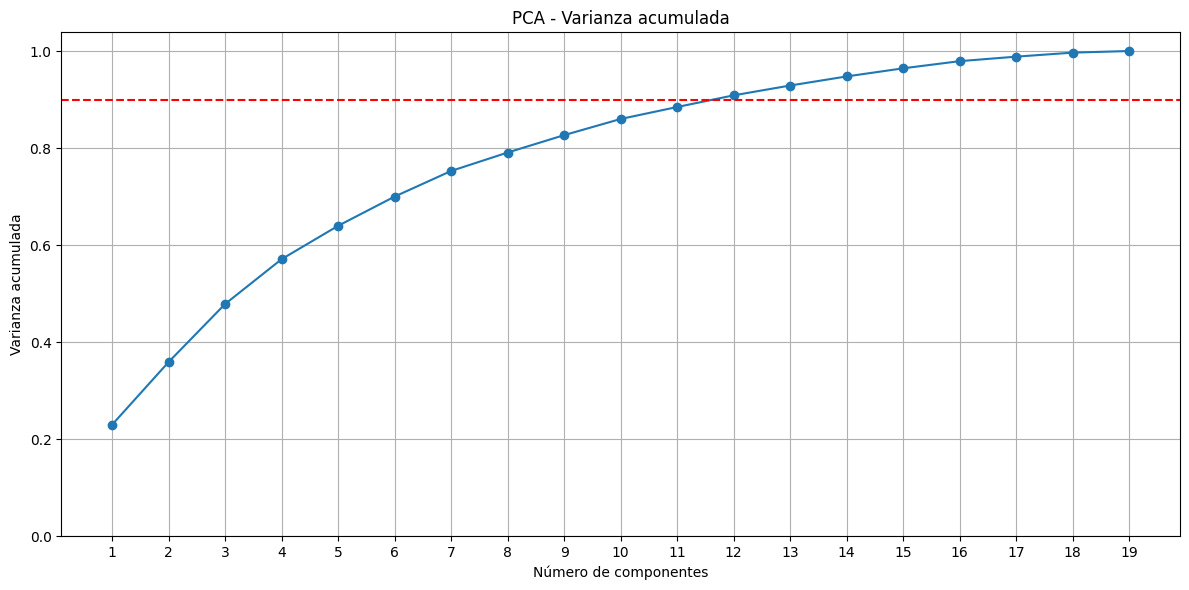

In [40]:
# varianza explicada por cada componente
explained_var = pca.explained_variance_ratio_

# varianza acumulada
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(12, 6))
plt.plot(component_range, cumulative_var, marker='o')
plt.xticks(component_range)
plt.ylim(bottom=0)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('PCA - Varianza acumulada')
plt.grid(True)
plt.axhline(y=0.9, color='red', linestyle='--', label='90% de varianza')
plt.tight_layout()
plt.show()

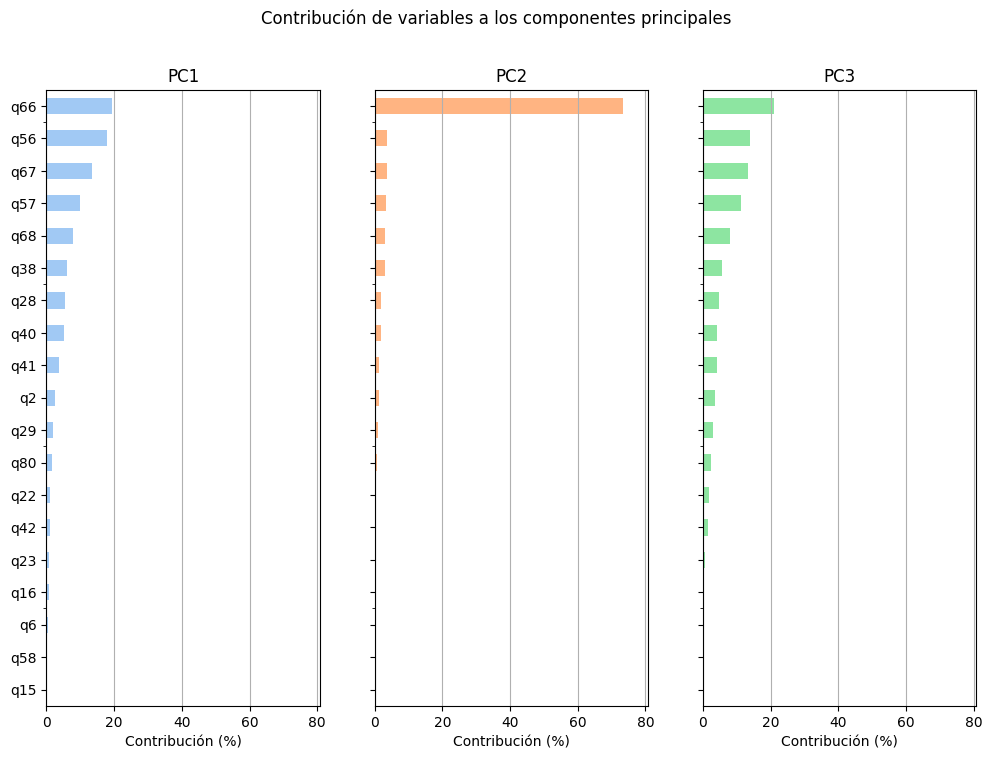

In [41]:
# Contribuciones porcentuales
contrib = (loadings**2)
contrib = contrib.div(contrib.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(1, 3, figsize=(12, 8), sharey=True)

pastel = sns.color_palette("pastel")

max_val = contrib[component_names].max().max()

for i, comp in enumerate(component_names[:3]):
    contrib[comp].sort_values().plot.barh(ax=ax[i], color=pastel[i])
    ax[i].set_title(comp)
    ax[i].set_xlabel("Contribución (%)")
    ax[i].grid(axis='x')
    ax[i].set_xlim(0, max_val * 1.1)

plt.suptitle("Contribución de variables a los componentes principales")
plt.show()

In [48]:
# Proyectamos los datos sobre los componentes principales
X_train_pca_arr = pca.transform(X_train_red)
X_test_pca_arr = pca.transform(X_test_red)

X_train_pca = pd.DataFrame(X_train_pca_arr, columns=component_names).iloc[:, :12]
X_test_pca = pd.DataFrame(X_test_pca_arr, columns=component_names).iloc[:, :12]

df_pca = X_train_pca.copy()
df_pca[target] = y_train_red
df_pca.head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,En Riesgo
0,0.611685,0.308022,0.886755,1.333478,-0.306440,0.429193,-0.492115,0.611072,-0.044968,0.501642,0.068375,0.281608,0
1,-0.878332,0.280881,-0.097302,-0.294447,-0.133548,-0.057197,-0.085792,-0.227640,-0.688982,0.094397,0.022493,-0.065328,0
2,-0.284576,-0.649840,-0.537615,0.516441,-0.693030,0.264112,-0.217430,0.065717,-0.032067,0.165434,-0.011572,0.107904,1
3,-1.084418,0.180509,-0.463536,0.164145,-0.057372,0.023440,0.124492,0.173631,-0.040660,0.050054,-0.023871,-0.008993,0
4,0.378426,-0.389595,0.155956,0.349677,-0.615604,0.366701,0.140505,0.225913,-0.158610,-0.293518,0.090880,0.335504,1
5,0.625985,-0.189289,-0.253336,0.254940,-0.688206,-0.557535,-0.479315,-0.074895,0.191703,0.057874,0.511886,-0.119971,0
6,-0.574793,0.576316,0.339570,-0.397345,-0.119732,-0.046847,-0.283801,0.312299,-0.297743,0.152593,0.170768,-0.368939,0
7,0.144736,-0.421268,-0.225164,-0.431241,0.616194,0.367935,-0.101647,0.425420,-0.004030,0.141274,0.035897,0.076893,0
8,0.342957,-0.612172,-0.007241,-0.133166,-0.707100,0.345441,0.413849,0.002856,-0.438285,0.186444,-0.033099,-0.511090,0
9,-0.793151,0.099420,-0.325879,0.115432,-0.015489,0.097714,0.442606,-0.513190,0.343240,0.126467,-0.077867,-0.050699,1


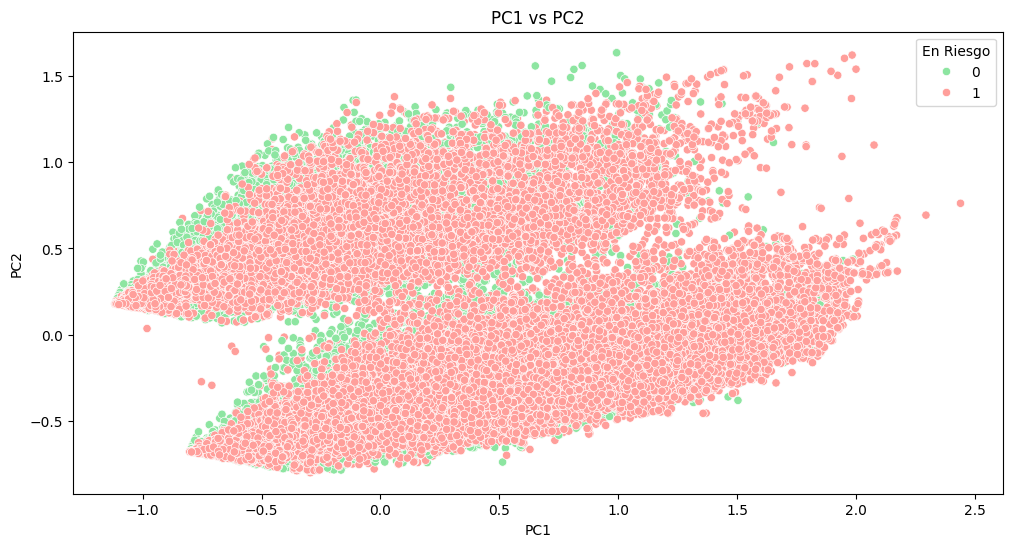

In [49]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue=target,
    palette={
        0: pastel[2],  # pastel green
        1: pastel[3]   # pastel red
    }
)

plt.title("PC1 vs PC2")
plt.show()

<Figure size 1200x600 with 0 Axes>

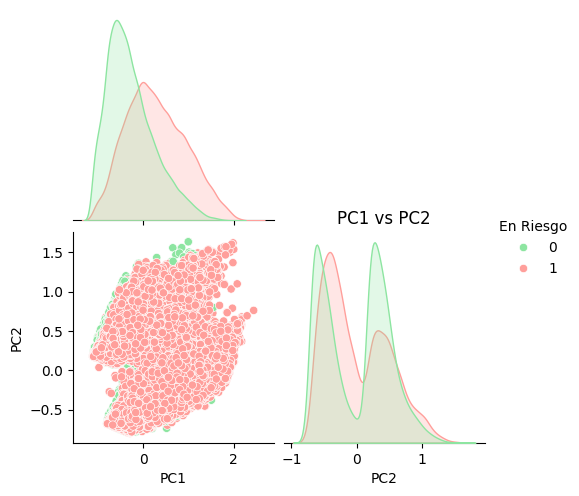

In [50]:
plt.figure(figsize=(12, 6))

sns.pairplot(
    df_pca,
    vars=["PC1", "PC2"],
    hue=target,
    palette={
        0: pastel[2],  # pastel green
        1: pastel[3]   # pastel red
    },
    corner=True
)

plt.title("PC1 vs PC2")
plt.show()

## 10. Conclusiones

In [ ]:
X_train_final = X_train_pca, y_train
X_test_final = 